# Directory for Figures tac

In [1]:
import os

# Définir le chemin de base et le répertoire à créer
base_dir = "G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2"
saving_dir = os.path.join(base_dir, "Plot_for_figure_tac2")

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(saving_dir):
    os.makedirs(saving_dir)
    print(f"Le répertoire '{saving_dir}' a été créé avec succès.")
else:
    print(f"Le répertoire '{saving_dir}' existe déjà.")

Le répertoire 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2\Plot_for_figure_tac2' existe déjà.


# 1. Plot Thq rec exemple (2023.11.09 - T1)

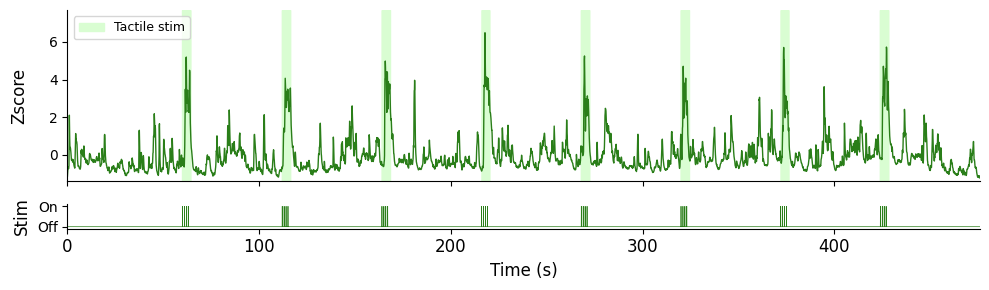

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 1. Chargement des données
final_df = pd.read_excel('G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Zscore_classic_tactile2.xlsx', sheet_name='Master_sheet')

# 2. Définir l'animal et le rec souhaités
animal_tac = '2023.10.06'  # Remplacez par l'animal souhaité

# 3. Filtrage des données pour l'animal et le rec spécifiés
df_tac_filtered = final_df[(final_df['animal'] == animal_tac)].copy()

# 4. Conversion du temps en secondes pour les deux DataFrames
df_tac_filtered.loc[:, 'time_sec'] = df_tac_filtered['time'] / 1000

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# 1er Subplot : Zscore rec raw
sns.lineplot(x='time_sec', y='Zscore', data=df_tac_filtered, ax=ax1, color='#2a7e19', linewidth=1, label=None)

# Ajuster les labels du premier subplot
ax1.set_ylabel('Zscore', labelpad=15)
ax1.set_ylim(-1.4, 7.7)
ax1.set_xlim(0, 476)

# Définir les périodes "TS" pour les deux DataFrames avec des couleurs transparentes
thermic_color = '#d9fdd2'  #'#2fef10'  # Couleur pour la période thermic

# Périodes de stimulation thermiques
ts_periods_thermic = df_tac_filtered[df_tac_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for i, row in ts_periods_thermic.iterrows():
    start_time_tac_raw = row['time'] / 1000
    end_time_tac_raw = (row['time'] + 2000) / 1000  # Conversion en secondes (3.9s)
    ax1.axvspan(start_time_tac_raw, end_time_tac_raw, color=thermic_color, zorder=0, label='Tactile stim')

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# Définir les périodes de stimulation
stim_periods = {
    'TS_1': (60, 63),
    'TS_2': (112, 115),
    'TS_3': (164, 167),
    'TS_4': (216, 219),
    'TS_5': (268, 271),
    'TS_6': (320, 323),
    'TS_7': (372, 375),
    'TS_8': (424, 427)
}


# Générer une série temporelle pour tracer les pulses
time_series = np.linspace(0, df_tac_filtered['time_sec'].max(), int(df_tac_filtered['time_sec'].max() * 100))  # Temps échantillonné à 10 ms
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.05  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajout des pulses en fonction des périodes thermiques
for period, (start, end) in stim_periods.items():
    # Calculer les positions des 5 barres (espacées uniformément)
    pulse_times = np.linspace(start, end, num_pulses)

    # Placer les pulses dans la série temporelle
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Deuxième Subplot : Pulses carrés
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=0.5)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Enlever les bordures
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 10,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})


plt.tight_layout()



# Afficher le graphique
plt.show()


# 2. Plot PSTC

La valeur maximale de la courbe moyenne est 2.6579 et elle se produit à 1.8000 secondes.


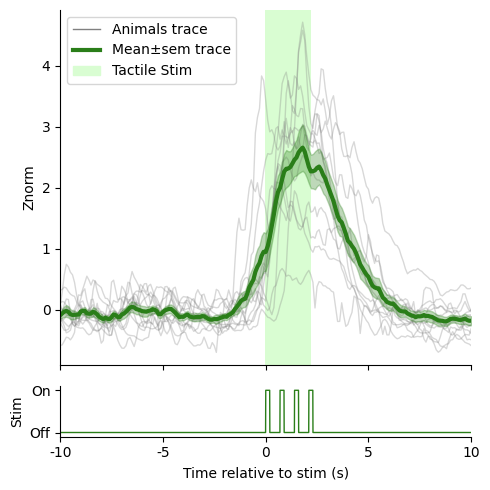

In [3]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np

# Répertoire contenant les fichiers Excel
input_directory = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Tac2_Trial_Mean_SEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory, 'Df_Zscore_classic_tactile2_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Znorm', 
        color=gray_color, linewidth=1, ax=ax1, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax1.plot([], [], color=gray_color, linewidth=1, label='Animals trace')  # Légende unique

# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
ax1.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Znorm'], 
    color='#2a7e19', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Znorm
ax1.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Znorm'] - SEM_zscore['Mean_Znorm'], 
    mean_zscore['Mean_Znorm'] + SEM_zscore['Mean_Znorm'], 
    color='#2a7e19', alpha=0.3, zorder=2, label=None
)

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Znorm'].min()
y_max = df_combined['Mean_Znorm'].max()

# Ajuster les limites de l'axe y
ax1.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))  # Ajouter une petite marge autour des données

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax1.fill_between(
            df_combined['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax1.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax1.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)

# Ajouter la légende au premier subplot
ax1.legend()

ax1.set_ylabel('Znorm')

ax1.set_xticks([-10, -5, 0, 5, 10])
ax1.set_xticklabels(['-10', '-5', '0', '5', '10'])
ax1.set_xlim(-10, 10)

# Ajuster les ticks de l'axe y 
time_range = (-10, 10)  # Définir la plage de temps sur laquelle calculer y_min et y_max
df_filtered_time = df_combined[(df_combined['time_sec'] >= time_range[0]) & (df_combined['time_sec'] <= time_range[1])]  # Filtrer les données
y_min_time_range = df_filtered_time['Mean_Znorm'].min()
y_max_time_range = df_filtered_time['Mean_Znorm'].max()
space = 0.2
ax1.set_ylim(y_min_time_range - space, y_max_time_range + space)

# Deuxième Subplot : Pulses carrés
# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(df_combined))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    pulse_times = np.linspace(start_time, end_time, num_pulses)
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()

# Identifier la valeur maximale et son temps associé
max_value = mean_zscore['Mean_Znorm'].max()
max_time = mean_zscore.loc[mean_zscore['Mean_Znorm'].idxmax(), 'time_sec']

# Afficher le résultat
print(f"La valeur maximale de la courbe moyenne est {max_value:.4f} et elle se produit à {max_time:.4f} secondes.")


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout ()



# Afficher le graphique
plt.show()

# 3. Combo PSTC and Heatmap

La valeur maximale de Z-score_norm entre 0 et 32.1 secondes est : 6.81740252782813


C:\Users\zayan\AppData\Local\Temp\ipykernel_90716\1745313802.py:78: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_heatmap_combined = df_tac.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
C:\Users\zayan\AppData\Local\Temp\ipykernel_90716\1745313802.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


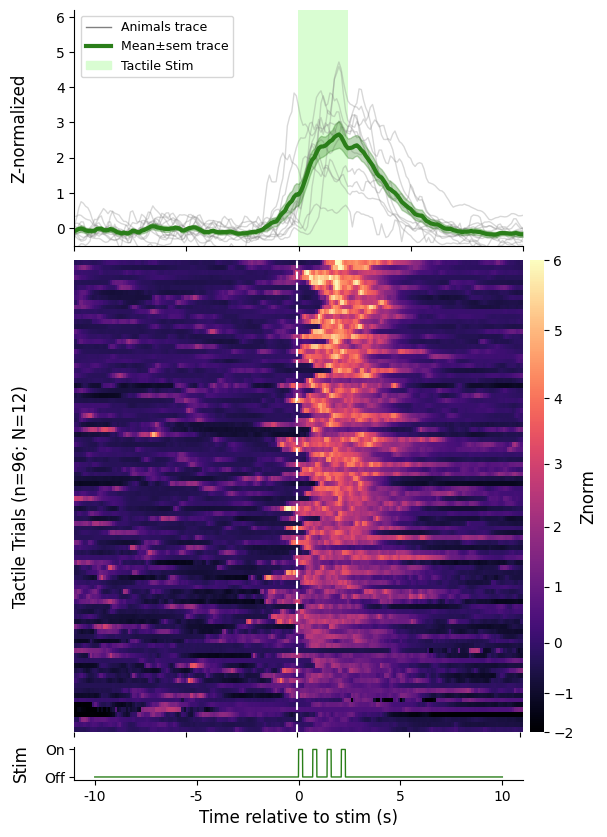

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Tac2_Trial_Mean_SEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory, 'Df_Zscore_classic_tactile2_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes


########################################################## HEATMAP #####################################################################

# Lire le fichier Excel
file_path_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Zscore_classic_tactile2_stim.xlsx'
df_tac = pd.read_excel(file_path_tac)

# # Trouver la valeur maximale de la colonne 'Znorm'
# max_znorm_value = df_tac['Znorm'].max()
# print("La valeur maximale de Znorm est :", max_znorm_value)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

add_stim_column(df_tac, 'Tactile')

# Convertir Stim_Time en secondes
df_tac['Stim_Time_sec'] = df_tac['Stim_Time'] / 1000

# Filtrer les données pour les time_sec compris entre 0 et 3.9
df_filtered = df_tac[(df_tac['Stim_Time_sec'] >= 0) & (df_tac['Stim_Time_sec'] <= 2.1)]

# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
max_znorm_value = df_filtered['Znorm'].max()

print("La valeur maximale de Znorm entre 0 et 2.1 secondes est :", max_znorm_value)

# Filtrer et calculer la somme de Znorm pour Stim_Time_sec entre 0 et 10 s, pour trier les trials
df_tac_filtered = df_tac[(df_tac['Stim_Time_sec'] >= 0) & (df_tac['Stim_Time_sec'] <= 10)]
trial_sums = df_tac_filtered.groupby('Stim')['Znorm'].max().sort_values(ascending=False)

# Réorganiser le DataFrame initial en fonction des trials triés par Znorm total
df_tac['Stim'] = pd.Categorical(df_tac['Stim'], categories=trial_sums.index, ordered=True)
df_tac = df_tac.sort_values('Stim')

# Créer la heatmap pour le DataFrame trié
df_heatmap_combined = df_tac.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
df_heatmap_combined = df_heatmap_combined.join(df_tac[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Znorm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1, label='Animals trace')  # Légende unique

# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Znorm'], 
    color='#2a7e19', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Znorm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Znorm'] - SEM_zscore['Mean_Znorm'], 
    mean_zscore['Mean_Znorm'] + SEM_zscore['Mean_Znorm'], 
    color='#2a7e19', alpha=0.3, zorder=2, label=None
)

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Znorm'].min()
y_max = df_combined['Mean_Znorm'].max()

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 10 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax0.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad = 20)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.5, 6.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé de couleurs avec une normalisation
norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)
base_palette = sns.color_palette("magma", as_cmap=True)
heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1)

# Ligne verticale pour marquer 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])


# Définir les étiquettes de l'axe x (de -10 à 10 avec un pas de 5)
ax1.set_xticks([df_heatmap_combined.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

ax1.set_yticks([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')  # Supprimer les étiquettes de l'axe y

# Marquer les trials Tactile
num_tac_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Tactile'])
ax1.text(-20, num_tac_trials / 2, f'Tactile Trials (n={num_tac_trials}; N=12)', fontsize=12, color='black', va='center', ha='right', rotation='vertical')


################# Tactile stim #################

ax2 = plt.subplot(gs[2, 0])

# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(df_combined))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    pulse_times = np.linspace(start_time, end_time, num_pulses)
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Ajuster les marges et sauvegarder
plt.tight_layout()



plt.show()


# 4. Ploting AUC

### 4.1. N = animals


TB : Mean: 0.5190, SEM: 0.1502, n:12
Test de Shapiro-Wilk
  Stat = 0.8001, p-value = 0.0094
    -> Les données ne suivent pas une distribution normale.

TS : Mean: 19.9660, SEM: 1.9975, n:12
Test de Shapiro-Wilk
  Stat = 0.9147, p-value = 0.2450
    -> Les données suivent une distribution normale.

PTS : Mean: 5.5488, SEM: 1.1485, n:12
Test de Shapiro-Wilk
  Stat = 0.9227, p-value = 0.3088
    -> Les données suivent une distribution normale.

Test de Friedman pour AUC_Znorm_persec (Tactile):
Chi-square: 24.0, p-value: 6.144212353328207e-06
Comparaisons post-hoc (AUC_Znorm_persec, Tactile) :
          PTS            TB            TS
PTS  1.000000  1.678755e-02  2.827858e-02
TB   0.016788  1.000000e+00  2.404829e-07
TS   0.028279  2.404829e-07  1.000000e+00


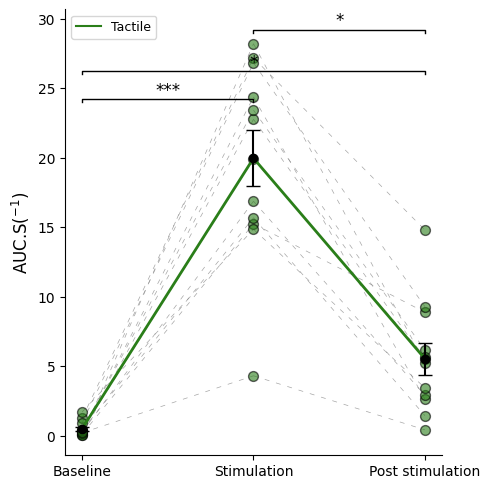

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)

# Ajouter une colonne pour identifier la condition
df_auc_tac['Condition'] = 'Tactile'

# Définir les périodes
periods = ['TB', 'TS', 'PTS']

# Fonction pour calculer les statistiques (moyenne, SEM, taille d'échantillon) et effectuer le test de Shapiro-Wilk
def calculate_stats(df, condition_name, variable_name):
    stats = {}
    shapiro_results = {}
    for period in periods:
        data = df[(df['Condition'] == condition_name) & (df['Period'] == period)][variable_name]
        size = len(data)
        mean = data.mean()
        sem = data.sem()
        
        # Effectuer le test de Shapiro-Wilk si l'échantillon est suffisant
        if size >= 3:
            shapiro_stat, shapiro_p = shapiro(data)
        else:
            shapiro_stat, shapiro_p = np.nan, np.nan  # Test non applicable
        
        stats[period] = {'Mean': mean, 'SEM': sem, 'n': size}
        shapiro_results[period] = {'Shapiro_stat': shapiro_stat, 'Shapiro_p': shapiro_p}
        
        # Afficher les résultats
        print(f"\n{period} : Mean: {mean:.4f}, SEM: {sem:.4f}, n:{size}")
        if not np.isnan(shapiro_stat):
            print(f"Test de Shapiro-Wilk")
            print(f"  Stat = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
            if shapiro_p < 0.05:
                print("    -> Les données ne suivent pas une distribution normale.")
            else:
                print("    -> Les données suivent une distribution normale.")
        else:
            print("  Test de Shapiro-Wilk: Non applicable (n < 3)")
    
    return stats, shapiro_results

# Calculer et afficher les statistiques pour la condition "Tactile"
stats_tac, shapiro_results_tac = calculate_stats(df_auc_tac, 'Tactile', 'AUC_Znorm_persec')


# Fonction pour effectuer le test de Friedman et les comparaisons post-hoc
def friedman_posthoc(df, variable_name, condition_name):
    friedman_test = friedmanchisquare(
        df[df['Period'] == 'PTS'][variable_name],
        df[df['Period'] == 'TB'][variable_name],
        df[df['Period'] == 'TS'][variable_name]
    )
    print(f"\nTest de Friedman pour {variable_name} ({condition_name}):")
    print(f"Chi-square: {friedman_test.statistic}, p-value: {friedman_test.pvalue}")

    posthoc_results = None
    if friedman_test.pvalue < 0.05:
        posthoc_results = posthoc_dunn(df, val_col=variable_name, group_col='Period', p_adjust='bonferroni')
        print(f"Comparaisons post-hoc ({variable_name}, {condition_name}) :")
        print(posthoc_results)
    return friedman_test, posthoc_results

# Appliquer le test de Friedman pour chaque variable
friedman_test_auc_tac, posthoc_results_auc_tac = friedman_posthoc(df_auc_tac, 'AUC_Znorm_persec', 'Tactile')

# Filtrer les données par période pour chaque variable
df_periods = {
    'Tactile': {period: df_auc_tac[(df_auc_tac['Period'] == period) & (df_auc_tac['Condition'] == 'Tactile')] for period in periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
colors = {'AUC_tac': '#2a7e19'
}
border_colors = {key: 'black' for key in colors}


# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_periods, condition_name, variable_name, color, border_color):
    means = {period: df_periods[condition_name][period][variable_name].mean() for period in periods}
    sems = {period: df_periods[condition_name][period][variable_name].sem() for period in periods}
    for period in periods:
        y_values = df_periods[condition_name][period][variable_name].values
        x_values = [positions[period]] * len(y_values)
        plt.scatter(x_values, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.6, marker='o', s=50, zorder=1)
        mean_value = means[period]
        sem_value = sems[period]
        plt.errorbar(positions[period], mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems


# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_tac, sems_tac = plot_variable(df_periods, 'Tactile', 'AUC_Znorm_persec', colors['AUC_tac'], border_colors['AUC_tac'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_tactile = mlines.Line2D([], [], color=colors['AUC_tac'], label='Tactile')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_tactile], loc='upper left')


# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color):
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]], positions[periods[i + 1]]
        y1, y2 = means[periods[i]], means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_tac, 'AUC_tac', colors['AUC_tac'])


# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_animal(df_auc_tac, condition_name, variable_name,color):
    # Filtrer par condition et par animal
    for animal in df_auc_tac[df_auc_tac['Condition'] == condition_name]['Animal'].unique():
        animal_data = df_auc_tac[(df_auc_tac['Condition'] == condition_name) & (df_auc_tac['Animal'] == animal)]
        
        # Relier les points pour chaque période pour cet animal
        for i, period in enumerate(periods[:-1]):
            x1 = positions[period] 
            x2 = positions[periods[i + 1]]
            y1 = animal_data[animal_data['Period'] == period][variable_name].values[0]
            y2 = animal_data[animal_data['Period'] == periods[i + 1]][variable_name].values[0]
            
            # Tracer une ligne entre les points
            plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10), linewidth=0.5, alpha=0.7, zorder=0)

plot_connections_per_animal(df_auc_tac, 'Tactile', 'AUC_Znorm_persec', colors['AUC_tac'])


def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.2, fontsize=12):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Afficher les résultats du test de Dunn entre les périodes pour la condition tactile
y_offset = 22    # Initialisation du décalage vertical pour les barres de significativité
spacing_between_bars = 2  # Espacement entre chaque barre de significativité

if posthoc_results_auc_tac is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_auc_tac.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = positions[period_1]  # Position sur l'axe des x
                    x2 = positions[period_2]  # Position sur l'axe des x
                    significance_y_position = y_offset + idx + spacing_between_bars
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut




# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
# plt.grid(axis='y')

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()


plt.show()


### 4.2. N = trials


Statistiques descriptives et test de Shapiro-Wilk :
  Period       Mean       SEM  Sample_Size  Shapiro_Statistic  Shapiro_p-value
0     TB   0.518998  0.083883           96           0.814605     1.234046e-09
1     TS  19.965984  0.966552           96           0.994994     9.788692e-01
2    PTS   5.548790  0.591298           96           0.985321     3.630879e-01

Test de Friedman pour AUC_Znorm_persec (Tactile):
Chi-square: 152.77083333333326, p-value: 6.702472546636017e-34
Comparaisons post-hoc (AUC_Znorm_persec, Tactile) :
              PTS            TB            TS
PTS  1.000000e+00  7.190807e-08  8.758993e-15
TB   7.190807e-08  1.000000e+00  6.594358e-41
TS   8.758993e-15  6.594358e-41  1.000000e+00


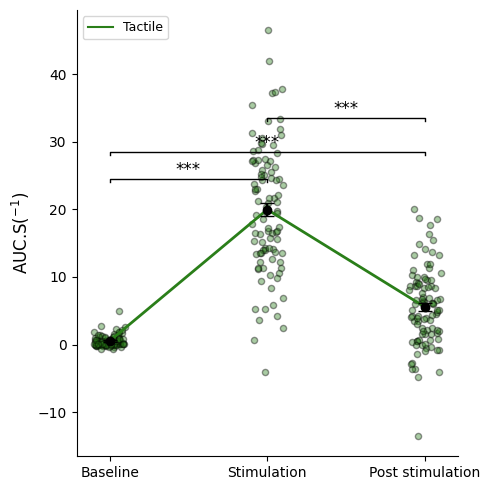

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon, shapiro
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines

# Chemin vers le fichier Excel
file_path_auc_tac_trials = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'

# Charger les données
df_auc_tac_trial = pd.read_excel(file_path_auc_tac_trials)

# Ajouter une colonne pour identifier la condition
df_auc_tac_trial['Condition'] = 'Tactile'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac_trial['Period_type'] = df_auc_tac_trial['Period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']

# Calcul des statistiques descriptives et test de Shapiro
results = []  # Pour stocker les résultats

for period in Periods:
    # Filtrer les données pour la période
    period_data = df_auc_tac_trial[df_auc_tac_trial['Period_type'] == period]['AUC_Znorm_persec']

    # Calculer les statistiques descriptives
    mean_value = period_data.mean()
    sem_value = period_data.sem()
    sample_size = period_data.count()

    # Effectuer le test de Shapiro-Wilk
    shapiro_stat, shapiro_p = shapiro(period_data)

    # Stocker les résultats
    results.append({
        'Period': period,
        'Mean': mean_value,
        'SEM': sem_value,
        'Sample_Size': sample_size,
        'Shapiro_Statistic': shapiro_stat,
        'Shapiro_p-value': shapiro_p
    })

# Créer un DataFrame pour afficher les résultats
results_df = pd.DataFrame(results)

# Afficher les résultats
print("\nStatistiques descriptives et test de Shapiro-Wilk :")
print(results_df)
# Fonction pour effectuer le test de Friedman et les comparaisons post-hoc
def friedman_posthoc(df, variable_name, condition_name):
    friedman_test = friedmanchisquare(
        df[df['Period_type'] == 'PTS'][variable_name],
        df[df['Period_type'] == 'TB'][variable_name],
        df[df['Period_type'] == 'TS'][variable_name]
    )
    print(f"\nTest de Friedman pour {variable_name} ({condition_name}):")
    print(f"Chi-square: {friedman_test.statistic}, p-value: {friedman_test.pvalue}")

    posthoc_results = None
    if friedman_test.pvalue < 0.05:
        posthoc_results = posthoc_dunn(df, val_col=variable_name, group_col='Period_type', p_adjust='bonferroni')
        print(f"Comparaisons post-hoc ({variable_name}, {condition_name}) :")
        print(posthoc_results)
    return friedman_test, posthoc_results

# Appliquer le test de Friedman pour chaque variable
friedman_test_auc_tac_trial, posthoc_results_auc_tac_trial = friedman_posthoc(df_auc_tac_trial, 'AUC_Znorm_persec', 'Tactile')

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Tactile': {Period: df_auc_tac_trial[(df_auc_tac_trial['Period_type'] == Period) & (df_auc_tac_trial['Condition'] == 'Tactile')] for Period in Periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
colors = {
    'AUC_Znorm_persec_Tactile': '#2a7e19'
}
border_colors = {key: 'black' for key in colors}

# Fonction pour ajouter du jitter aux données
def add_jitter(x_values, jitter_strength=0.1):
    return x_values + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_values))

# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_Periods, condition_name, variable_name, color, border_color):
    means = {Period: df_Periods[condition_name][Period][variable_name].mean() for Period in Periods}
    sems = {Period: df_Periods[condition_name][Period][variable_name].sem() for Period in Periods}
    for Period in Periods:
        y_values = df_Periods[condition_name][Period][variable_name].values
        x_values = [positions[Period]] * len(y_values)
        
        # Ajouter du jitter aux positions des points
        x_values_jittered = add_jitter(x_values)
        
        plt.scatter(x_values_jittered, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.4, marker='o', s=20, zorder=1)
        mean_value = means[Period]
        sem_value = sems[Period]
        plt.errorbar(positions[Period], mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems

# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_tac, sems_tac = plot_variable(df_Periods, 'Tactile', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_Tactile'], border_colors['AUC_Znorm_persec_Tactile'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_tactile = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_Tactile'], label='Tactile')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_tactile], loc='upper left')

# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color):
    for i in range(len(Periods) - 1):
        x1, x2 = positions[Periods[i]], positions[Periods[i + 1]]
        y1, y2 = means[Periods[i]], means[Periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_tac, 'AUC_Znorm_persec_Tactile', colors['AUC_Znorm_persec_Tactile'])


# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_trials_grouped(df_auc_tac_trial, condition_name, variable_name, color):
    # Filtrer par condition
    condition_data = df_auc_tac_trial[df_auc_tac_trial['Condition'] == condition_name]

    # Grouper les données par Animal, Rec et Trial
    grouped_data = condition_data.groupby(['Animal', 'Trial'])

    # Parcourir chaque groupe
    for (animal, trial), group in grouped_data:
        # Relier les points pour chaque période pour cet animal et cet enregistrement
        for i, Period in enumerate(Periods[:-1]):
            # Vérifier que les données des deux périodes existent
            if Period in group['Period'].values and Periods[i + 1] in group['Period'].values:
                x1 = positions[Period]
                x2 = positions[Periods[i + 1]]
                y1 = group[group['Period'] == Period][variable_name].values[0]
                y2 = group[group['Period'] == Periods[i + 1]][variable_name].values[0]

                # Tracer une ligne entre les points
                plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10),
                         linewidth=0.5, alpha=0.7, zorder=0)

# Appeler la fonction pour tracer les connexions
plot_connections_per_trials_grouped(df_auc_tac_trial, 'Tactile', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_Tactile'])


# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.35

def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=12):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Afficher les résultats du test de Dunn entre les périodes pour la condition Tactile
y_offset = 20 # Initialisation du décalage vertical pour les barres de significativité
spacing_between_bars = 4  # Espacement entre chaque barre de significativité

if posthoc_results_auc_tac_trial is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_auc_tac_trial.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = positions[period_1]  # Position sur l'axe des x
                    x2 = positions[period_2]  # Position sur l'axe des x
                    significance_y_position = y_offset + idx + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


plt.xticks([positions[Period] for Period in Periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()


plt.show()

# 5. Response rate by condition

### with N = animals

taux moyen de réponse tactile =89.58333333333333±6.122435558804777

Taille des échantillons : 12


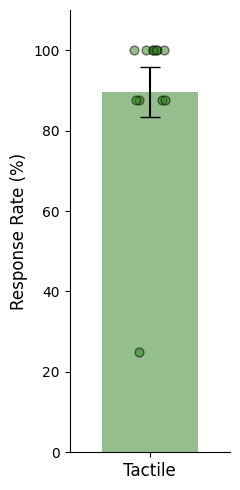

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Chemin du fichier Excel
file_path_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Lecture du fichier Excel
df_tac_response = pd.read_excel(file_path_tac)

# Calcul du taux de réponse moyen par animal
response_data_tac = df_tac_response.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_tac['response_rate'] *= 100  # Conversion en pourcentage

# Calcul de la moyenne et de l'écart-type de réponse par animal
mean_response_per_animal = response_data_tac.groupby('animal')['response_rate'].mean()

# Calcul des statistiques globales
mean_response = mean_response_per_animal.mean()
sem_response = mean_response_per_animal.sem()
print (f"taux moyen de réponse tactile ={mean_response}±{sem_response}")
plt.figure(figsize=(2.5, 5))

# Tracé de la barre
plt.bar(
    [0.5],  # Position centrale pour la barre
    mean_response,
    width=0.6,  # Changez cette valeur pour ajuster la largeur
    yerr=sem_response,
    color='#2a7e19',
    alpha=0.5,
    capsize=7,
    label='tactile Stim'
)

# Ajout des points individuels avec jitter
np.random.seed(42)  # Assurer la reproductibilité
jitter = np.random.uniform(-0.1, 0.1, size=len(mean_response_per_animal))  # Générer un jitter aléatoire
x_positions = [0.5 + j for j in jitter]  # Ajouter le jitter autour de x=0.5

plt.scatter(
    x_positions,  # Utiliser les positions avec jitter
    mean_response_per_animal,
    color='#2a7e19',
    alpha=0.5,
    edgecolor='black',
    s=40
)


# Vérification des tailles d'échantillons
sample_size_tac = len(mean_response_per_animal)  # Taille de l'échantillon pour Tactile

print(f"\nTaille des échantillons : {sample_size_tac}")

# Mise en forme du graphique
plt.xticks([0.5], ['Tactile'])  # Placez l'étiquette au centre
plt.xlim(0, 1)  # Ajustez les limites pour encadrer la barre
plt.ylabel("Response Rate (%)")
plt.ylim(0, 110)


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()



plt.show()


# 6. Above threshold rate

### 6.1. with n = animals


=== Résultats des Statistiques ===
             period  mean_response_tac  sem_response_tac   n
0          Baseline           3.083333          0.659347  12
1       Stimulation          57.341270          7.635550  12
2  Post stimulation          15.429688          3.448734  12

Test de normalité pour la période TB : n = 12
Statistique = 0.8622, p-value = 0.0521

Test de normalité pour la période TS : n = 12
Statistique = 0.9722, p-value = 0.9324

Test de normalité pour la période PTS : n = 12
Statistique = 0.9233, p-value = 0.3148

Résultats du Test de Friedman :
n (TB) = 12
n (TS) = 12
n (PTS) = 12
Statistique = 19.5000, p-value = 0.0001

Test de Dunn post-hoc pour comparer les périodes :
           TS        TB       PTS
TS   1.000000  0.000004  0.085657
TB   0.000004  1.000000  0.023816
PTS  0.085657  0.023816  1.000000


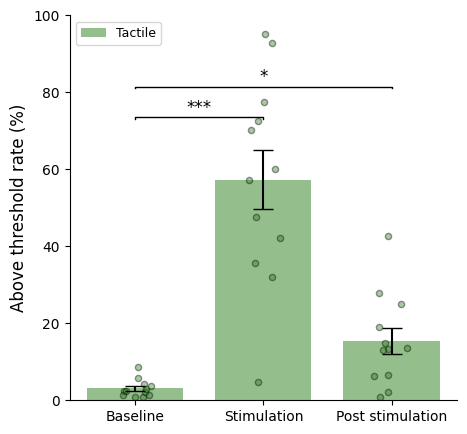

In [33]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for period in ['TB', 'TS', 'PTS']:
    period_data = df_tac[df_tac['period_type'] == period]

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_tac_animal = df_tac.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()

# Moyenne des animaux pour chaque période (pour obtenir 1 valeur moyenne par période)
mean_tac = mean_tac_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_tac = mean_tac_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

# Calcul de la taille d'échantillon pour chaque période
sample_sizes = mean_tac_animal.groupby('period_type')['Norm_response_rate'].count().reindex(period_order)

# Créer un DataFrame avec les moyennes et sem pour chaque période
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_tac': mean_tac['Norm_response_rate'],
    'sem_response_tac': sem_tac['Norm_response_rate'],
    'n' : sample_sizes.values
})

# Afficher les statistiques
print("\n=== Résultats des Statistiques ===")
print(mean_response_data)


# Effectuer le test de normalité pour chaque période
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    period_data = mean_tac_animal[mean_tac_animal['period_type'] == period]['Norm_response_rate']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')

# Effectuer le test de Friedman pour les périodes
print("\nRésultats du Test de Friedman :")
friedman_results = {}

# Organiser les données par période
period_data = [mean_tac_animal[mean_tac_animal['period_type'] == period]['Norm_response_rate'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results['p_value'] = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")

# Initialiser posthoc_results
posthoc_results = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour comparer les périodes
    print("\nTest de Dunn post-hoc pour comparer les périodes :")
    
    # Test de Dunn post-hoc
    posthoc_results = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results)

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition Tactile
plt.bar(mean_response_data['period'],
        height=mean_response_data['mean_response_tac'],
        width=bar_width, 
        yerr=mean_response_data['sem_response_tac'],
        label='Tactile', 
        color='#2a7e19', 
        alpha=0.5, 
        capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    tac_values = mean_tac_animal[mean_tac_animal['period_type'] == period]['Norm_response_rate']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque période avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in tac_values],
                tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.4)

# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=12):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.15, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset = 65  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
# y_offset = max(mean_response_data['mean_response_tac']) * 0.25  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 8  # Espacement entre chaque barre de significativité

if posthoc_results is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    # significance_y_position = max(mean_response_data['mean_response_tac'][idx], mean_response_data['mean_response_tac'][jdx]) + y_offset
                    significance_y_position = y_offset + idx + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,    # Taille des labels des axes
    'xtick.labelsize': 10,   # Taille des labels des ticks de l'axe X
    'ytick.labelsize': 10    # Taille des labels des ticks de l'axe Y
})

# Afficher le graphique
plt.show()


### 6.2. with n = Trials

             period  mean_response_tac  sem_response_tac   n
0          Baseline           3.083333          0.393385  96
1       Stimulation          57.341270          3.447384  96
2  Post stimulation          15.429688          1.400094  96

Test de normalité pour la période TB : n = 96
Statistique = 0.7959, p-value = 0.0000

Test de normalité pour la période TS : n = 96
Statistique = 0.9109, p-value = 0.0000

Test de normalité pour la période PTS : n = 96
Statistique = 0.9038, p-value = 0.0000

Résultats du Test de Friedman :
n (TB) = 96
n (TS) = 96
n (PTS) = 96
Statistique = 120.8483, p-value = 0.0000

Test de Dunn post-hoc pour comparer les périodes :
               TS            TB           PTS
TS   1.000000e+00  1.415767e-30  1.497881e-06
TB   1.415767e-30  1.000000e+00  1.594804e-10
PTS  1.497881e-06  1.594804e-10  1.000000e+00


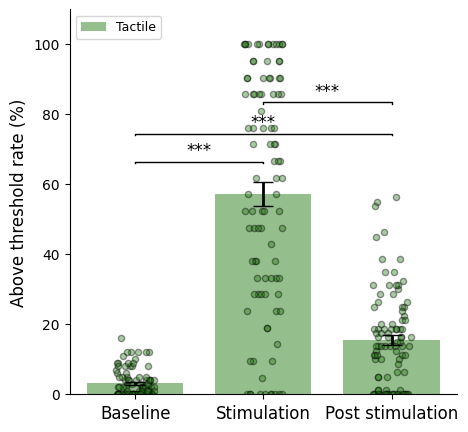

In [35]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_tac_trial = df_tac[df_tac['period_type'].isin(['TS', 'TB', 'PTS'])]

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = df_tac_trial.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_tac = df_tac_trial.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

# Calcul de la taille d'échantillon pour chaque période
sample_sizes_trial = df_tac_trial.groupby('period_type')['Norm_response_rate'].count().reindex(period_order)

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_trial = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_tac': mean_tac['Norm_response_rate'],
    'sem_response_tac': sem_tac['Norm_response_rate'],
    'n' : sample_sizes_trial.values
})

# Afficher les statistique
print(mean_response_trial)

# Effectuer le test de normalité pour chaque période
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    period_data = df_tac_trial[df_tac_trial['period_type'] == period]['Norm_response_rate']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour les périodes
print("\nRésultats du Test de Friedman :")
friedman_results = {}

# Organiser les données par période
period_data = [df_tac_trial[df_tac_trial['period_type'] == period]['Norm_response_rate'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results['p_value'] = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")

# Initialiser posthoc_results
posthoc_results = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour comparer les périodes
    print("\nTest de Dunn post-hoc pour comparer les périodes :")
    
    # Test de Dunn post-hoc
    posthoc_results = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results)

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période
bar_width = 0.75
x = range(len(mean_response_trial['period']))

# Barres pour la condition tactile sans erreur (seulement les barres)
plt.bar(mean_response_trial['period'],
        height=mean_response_trial['mean_response_tac'],
        width=bar_width, 
        label='Tactile', 
        color='#2a7e19', 
        alpha=0.5, 
        zorder=0
        )

# Ajouter les barres d'erreur pour chaque période (en utilisant plt.errorbar)
plt.errorbar(mean_response_trial['period'],
             mean_response_trial['mean_response_tac'],
             yerr=mean_response_trial['sem_response_tac'],
             fmt='none',  # Pas de marqueur supplémentaire pour les erreurs
             ecolor='black',  # Couleur des erreurs
             capsize=7,       # Taille des caps pour les erreurs
             elinewidth=2,    # Épaisseur des lignes d'erreur
             zorder=3         # Les erreurs seront au-dessus des barres
             )

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    tac_values = df_tac_trial[df_tac_trial['period_type'] == period]['Norm_response_rate']
    
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque période avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in tac_values],
                tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.4, zorder=0)


# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=12):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset = 58  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
# y_offset = max(mean_response_data['mean_response_tac']) + 1  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes

spacing_between_bars = 8  # Espacement entre chaque barre de significativité

if posthoc_results is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    # significance_y_position = max(mean_response_data['mean_response_tac'][idx], mean_response_data['mean_response_tac'][jdx]) + y_offset
                    significance_y_position = y_offset + idx + spacing_between_bars


                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_trial['period'])
plt.legend(loc='upper left')
plt.ylim(0, 110)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Afficher le graphique
plt.show()


# 7. Magnitude of the response

### 7.1. N = animals 

             period  mean_response_tac  sem_response_tac   n
0          Baseline           0.110680          0.021693  12
1       Stimulation           1.911215          0.245999  12
2  Post stimulation           0.508211          0.106631  12

Test de normalité pour la période TB : n = 12
Statistique = 0.8540, p-value = 0.0411

Test de normalité pour la période TS : n = 12
Statistique = 0.9261, p-value = 0.3407

Test de normalité pour la période PTS : n = 12
Statistique = 0.9421, p-value = 0.5260

Résultats du Test de Friedman :
n (TB) = 12
n (TS) = 12
n (PTS) = 12
Statistique = 19.5000, p-value = 0.0001

Test de Dunn pour comparer les périodes Thq :
           TS        TB       PTS
TS   1.000000  0.000004  0.099216
TB   0.000004  1.000000  0.020037
PTS  0.099216  0.020037  1.000000


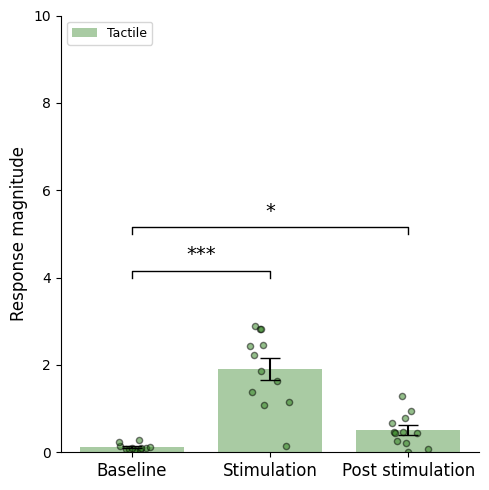

In [43]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
# tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Response_Magnitude.xlsx'
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Response_Magnitude_norm.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_tac], ['Tactile']):

    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')

    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_tac_animal = df_tac.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = mean_tac_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_tac = mean_tac_animal.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

# Calcul de la taille d'échantillon pour chaque période
sample_sizes = mean_tac_animal.groupby('period_type')['response_magnitude'].count().reindex(period_order)

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_tac': mean_tac['response_magnitude'],
    'sem_response_tac': sem_tac['response_magnitude'],
    'n' : sample_sizes.values
})

# Afficher les statistique
print(mean_response_data)

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}

    data_subset = mean_tac_animal
    period_data = data_subset[data_subset['period_type'] == period]['response_magnitude']

    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour chaque condition (Cool et Hot)
print("\nRésultats du Test de Friedman :")
friedman_results = {}

data = mean_tac_animal

# Organiser les données par période
period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")


# Initialiser posthoc_results
posthoc_results_magnitude = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour chaque condition après le test de Friedman
    print("\nTest de Dunn pour comparer les périodes Thq :")

    data = mean_tac_animal

    # Organiser les données par période
    period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

    # Test de Dunn post-hoc
    posthoc_results_magnitude = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results_magnitude.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results_magnitude.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results_magnitude)


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition tactile
plt.bar([p for p in x], mean_response_data['mean_response_tac'],
        width=bar_width, yerr=mean_response_data['sem_response_tac'],
        label='Tactile', color='#2a7e19', alpha=0.4, capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    Tac_values = mean_tac_animal[mean_tac_animal['period_type'] == period]['response_magnitude']

    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in Tac_values],
                Tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.5)


# Ajouter les barres de significativité du test de Dunn
# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.15, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.15, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset = 3  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 1  # Espacement entre chaque barre de significativité

if posthoc_results_magnitude is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_magnitude.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    # significance_y_position = max(mean_response_data['mean_response_tac'][idx], mean_response_data['mean_response_tac'][jdx]) + y_offset
                    significance_y_position = y_offset + idx + spacing_between_bars


                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim(0, 10)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()


plt.show()


### 7.2. N = Trials

             period  mean_response_tac  sem_response_tac   n
0          Baseline           0.110680          0.011861  96
1       Stimulation           1.911215          0.115647  96
2  Post stimulation           0.508211          0.043904  96

Test de normalité pour la période TB : n = 96
Statistique = 0.8607, p-value = 0.0000

Test de normalité pour la période TS : n = 96
Statistique = 0.9720, p-value = 0.0376

Test de normalité pour la période PTS : n = 96
Statistique = 0.9211, p-value = 0.0000

Résultats du Test de Friedman :
n (TB) = 96
n (TS) = 96
n (PTS) = 96
Statistique = 119.4575, p-value = 0.0000

Test de Dunn pour comparer les périodes Thq :
               TS            TB           PTS
TS   1.000000e+00  3.304781e-31  1.768818e-06
TB   3.304781e-31  1.000000e+00  5.535534e-11
PTS  1.768818e-06  5.535534e-11  1.000000e+00


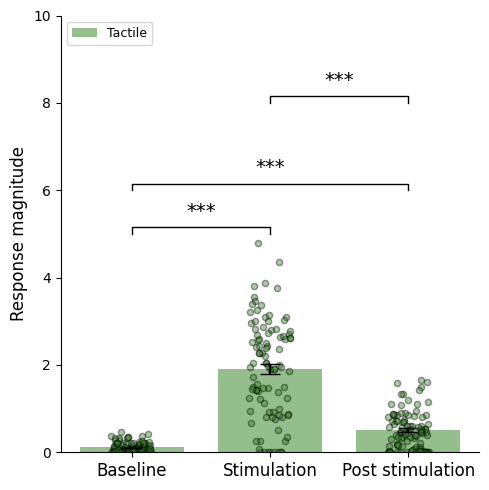

In [45]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, shapiro, friedmanchisquare


# Spécifier le chemin des fichiers Excel
# tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Response_Magnitude.xlsx'
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Response_Magnitude_norm.xlsx'


# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Compter le nombre d'observations par période et par animal
sample_sizes = df_tac.groupby(['animal', 'period_type']).size().reset_index(name='count')

# Vérifier si toutes les périodes ont exactement 24 observations par animal
for period in ['TB', 'TS', 'PTS']:
    period_data = sample_sizes[sample_sizes['period_type'] == period]

# Extraire le type de période (TS, TB, PTS)
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_tac_filtered = df_tac[df_tac['period_type'].isin(['TS', 'TB', 'PTS'])]


# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = df_tac_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_tac = df_tac_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

# Calcul de la taille d'échantillon pour chaque période
sample_sizes = df_tac_filtered.groupby('period_type')['response_magnitude'].count().reindex(period_order)

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_tac': mean_tac['response_magnitude'],
    'sem_response_tac': sem_tac['response_magnitude'],
    'n' : sample_sizes.values
})


# Afficher les statistique
print(mean_response_data)


# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}

    data_subset = df_tac_filtered
    period_data = data_subset[data_subset['period_type'] == period]['response_magnitude']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")
    
    stat, p_value = shapiro(period_data)
    normality_results[period]= {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour chaque condition
print("\nRésultats du Test de Friedman :")
friedman_results = {}

data = df_tac_filtered

# Organiser les données par période
period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")


# Initialiser posthoc_results
posthoc_magnitude_trials = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour chaque condition après le test de Friedman
    print("\nTest de Dunn pour comparer les périodes Thq :")

    data = df_tac_filtered

    # Organiser les données par période
    period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

    # Test de Dunn post-hoc
    posthoc_magnitude_trials = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_magnitude_trials.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_magnitude_trials.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_magnitude_trials)


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition Tactile
plt.bar([p for p in x], mean_response_data['mean_response_tac'],
        width=bar_width, yerr=mean_response_data['sem_response_tac'],
        label='Tactile', color='#2a7e19', alpha=0.5, capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    Tac_values = df_tac_filtered[df_tac_filtered['period_type'] == period]['response_magnitude']
     # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in Tac_values],
                Tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.4)



# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.15, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.15, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Ajouter les barres de significativité du test de Dunn
if isinstance(posthoc_magnitude_trials, pd.DataFrame):  # Vérifiez si c'est un DataFrame
    y_offset = 4
    spacing_between_bars = 1  # Espacement entre chaque barre de significativité

    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_magnitude_trials.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    # significance_y_position = max(mean_response_data['mean_response_tac'][idx], mean_response_data['mean_response_tac'][jdx]) + y_offset
                    significance_y_position = y_offset + idx + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut
else:
    print("Les résultats du test de Dunn ne sont pas disponibles ou ne sont pas significatifs.")



# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim (0,10)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

plt.show()


# 9. Sex effect

## 9.1. PSTC

Nombre d'animaux mâles (M) : 5
Nombre d'animaux femelles (F) : 7
La valeur maximale de Znorm pour les F (0-2.1s) est : 2.702886966763118
La valeur maximale de Znorm pour les M (0-2.1s) est : 2.603556632936862


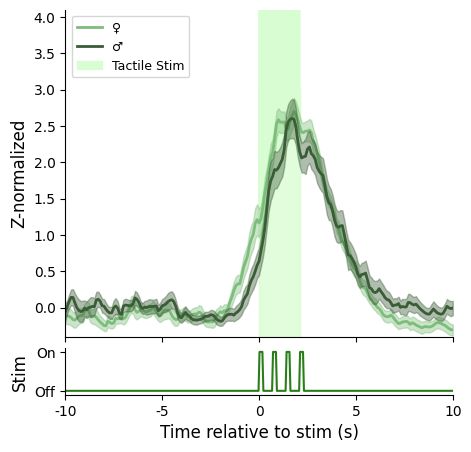

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Chemin vers le fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Zscore_classic_tactile2_stim.xlsx'

# Lire le fichier Excel
df_tactile = pd.read_excel(file_path)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_tactile['time_sec'] = df_tactile['Stim_Time'] / 1000

# Extraire le type de période (TB, TS, PTS)
df_tactile['Period_type'] = df_tactile['period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']

# Compter le nombre d'animaux par sexe
if 'animal' in df_tactile.columns:
    animal_count = df_tactile[['animal', 'sexe']].drop_duplicates().groupby('sexe').size()
    count_m = animal_count.get('M', 0)  # Nombre d'animaux mâles
    count_f = animal_count.get('F', 0)  # Nombre d'animaux femelles
    print(f"Nombre d'animaux mâles (M) : {count_m}")
    print(f"Nombre d'animaux femelles (F) : {count_f}")
else:
    print("La colonne 'animal' n'existe pas dans le fichier.")

# Grouper par 'sexe' et 'time_sec', puis calculer les moyennes et erreurs standards
grouped = df_tactile.groupby(['sexe', 'time_sec','Period_type']).agg(
    Mean_Zscore_norm=('Znorm', 'mean'),
    SEM_Zscore_norm=('Znorm', 'sem'),
).reset_index()

# Définir les couleurs pour chaque sexe
sex_colors = {
    'F': {'mean': '#7dbd7b', 'sem': '#7dbd7b'},  
    'M': {'mean': '#3a5c36', 'sem': '#3a5c36'}   
}

# Créer la figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Calculer les limites réelles pour l'axe y
y_min = grouped['Mean_Zscore_norm'].min()
y_max = grouped['Mean_Zscore_norm'].max()

# Tracer les courbes pour chaque sexe
for sexe, color in sex_colors.items():
    sexe_data = grouped[grouped['sexe'] == sexe]

    # Tracer la courbe moyenne pour le Z-score
    ax1.plot(
        sexe_data['time_sec'], sexe_data['Mean_Zscore_norm'],
        color=color['mean'], linewidth=2, label=f"{'♀' if sexe == 'F' else '♂'}"
    )

    # Ajouter une zone ombrée pour le SEM
    ax1.fill_between(
        sexe_data['time_sec'],
        sexe_data['Mean_Zscore_norm'] - sexe_data['SEM_Zscore_norm'],
        sexe_data['Mean_Zscore_norm'] + sexe_data['SEM_Zscore_norm'],
        color=color['sem'], alpha=0.4, zorder=2
    )

# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in grouped.iterrows():
    if row['Period_type'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax1.fill_between(
            grouped['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(grouped['time_sec'] >= start_time) & (grouped['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False


# Ajouter une seule entrée de légende stim
ax1.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)


# Remplir la zone au-dessus de l'ombre de la SEM (jusqu'au haut du graphique)
ax1.fill_between(
    grouped['time_sec'], 
    grouped['Mean_Zscore_norm'] + grouped['SEM_Zscore_norm'], 
    y_max +5,  # Limite supérieure réelle du graphique
    where=(grouped['time_sec'] >= start_time) & (grouped['time_sec'] <= end_time),
    color=color_ts, zorder=0
)

# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(grouped))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in grouped.iterrows():
    if row['Period_type'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False


# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1.5)

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized')
ax1.legend(loc="upper left")

# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.4, 4.1)
ax1.set_xlim(-10, 10)

ax1.set_xticks([-10, -5, 0, 5, 10])
ax1.set_xticklabels("")
ax1.set_xlim(-10, 10)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])
ax2.set_xlim(-10, 10)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


# Filtrer les données pour 'time_sec' entre 0 et 3.9
filtered_data = grouped[(grouped['time_sec'] >= 0) & (grouped['time_sec'] <= 2.1)]

# Trouver la valeur maximale de Z-score_norm pour chaque sexe
max_values_by_sex = filtered_data.groupby('sexe')['Mean_Zscore_norm'].max()

# Afficher les valeurs maximales pour chaque sexe
for sexe, max_value in max_values_by_sex.items():
    print(f"La valeur maximale de Znorm pour les {sexe} (0-2.1s) est : {max_value}")

#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout


# Afficher le graphique
plt.show()

## 9.2. AUC

##### 9.2.1.AUC (animals) --- ATTENTION STAT PAS FAITE

  Sexe Period       Mean       SEM  Sample_Size
0    M     TB   0.415229  0.221491            5
1    M     TS  18.124111  4.404484            5
2    M    PTS   6.172497  2.626765            5
3    F     TB   0.593120  0.212958            7
4    F     TS  21.281608  1.615400            7
5    F    PTS   5.103285  0.883581            7
Shapiro-Wilk Test (M, TB): W=0.775, p=0.050
Shapiro-Wilk Test (M, TS): W=0.905, p=0.441
Shapiro-Wilk Test (M, PTS): W=0.933, p=0.620
Shapiro-Wilk Test (F, TB): W=0.805, p=0.046
Shapiro-Wilk Test (F, TS): W=0.954, p=0.762
Shapiro-Wilk Test (F, PTS): W=0.905, p=0.364


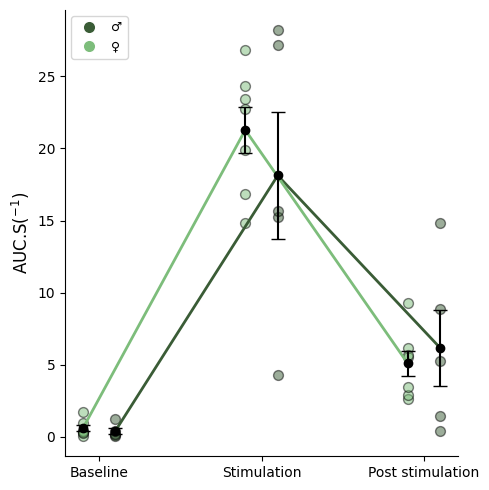

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from scipy.stats import friedmanchisquare
from scikit_posthocs import posthoc_dunn
import os

# Chemin vers le fichier Excel
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs pour les sexes
colors = {'M': '#3a5c36', 'F': '#7dbd7b'}
border_colors = {'M': 'black', 'F': 'black'}

# Fonction pour tracer les variables en fonction du sexe et collecter les statistiques
def plot_variable_sex(df, variable_name, condition_name, colors, border_colors):
    stats = []  # Liste pour collecter les statistiques (moyennes, SEM, tailles d'échantillons)

    for sex in df['Sexe'].unique():
        sex_data = df[df['Sexe'] == sex]
        for period in periods:
            period_data = sex_data[sex_data['Period'] == period][variable_name]

            mean_value = period_data.mean()
            sem_value = period_data.sem()
            sample_size = len(period_data)

            stats.append({
                'Sexe': sex,
                'Period': period,
                'Mean': mean_value,
                'SEM': sem_value,
                'Sample_Size': sample_size
            })

            # Test de Shapiro-Wilk pour la normalité
            if sample_size >= 3:  # Le test Shapiro nécessite au moins 3 échantillons
                stat, p_value = shapiro(period_data)
                print(f"Shapiro-Wilk Test ({sex}, {period}): W={stat:.3f}, p={p_value:.3f}")
            else:
                print(f"Shapiro-Wilk Test ({sex}, {period}): Non applicable (échantillon insuffisant)")

            # Tracer les points individuels
            x_offset = 0.1 if sex == 'M' else -0.1
            x_values = [positions[period] + x_offset] * len(period_data)
            y_values = period_data.values

            plt.scatter(x_values, y_values, color=colors.get(sex, 'gray'), edgecolor=border_colors.get(sex, 'black'),
                        linewidth=1, alpha=0.5, marker='o', s=50, zorder=1)

            # Tracer la moyenne et SEM
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)

    return stats

# Afficher les statistiques collectées
stats_df = pd.DataFrame(stats)
print(stats_df)

# Tracer les données et collecter les statistiques
plt.figure(figsize=(5, 5))
stats = plot_variable_sex(df_auc_tac, 'AUC_Znorm_persec', 'Tactile', colors, border_colors)

# Fonction pour afficher les connexions entre les moyennes
def plot_connections(stats, sex, variable_name, color):
    means = {stat['Period']: stat['Mean'] for stat in stats if stat['Sexe'] == sex}
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]] + (0.1 if sex == 'M' else -0.1), positions[periods[i + 1]] + (0.1 if sex == 'M' else -0.1)
        y1, y2 = means[periods[i]], means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Ajouter les connexions pour chaque sexe
for sex in df_auc_tac['Sexe'].unique():
    plot_connections(stats, sex, 'AUC_Znorm_persec', colors[sex])

# Réglages du graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')

# Ajouter une légende
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['M'], markersize=9, label='♂'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['F'], markersize=9, label='♀')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()



##### 9.2.2. AUC of TS period (aniamls)

Sex: M
  Mean: 18.1241
  SEM: 4.4045
  Sample Size: 5
  Shapiro-Wilk Stat: 0.9054
  Shapiro-Wilk p-value: 0.4407

Sex: F
  Mean: 21.2816
  SEM: 1.6154
  Sample Size: 7
  Shapiro-Wilk Stat: 0.9536
  Shapiro-Wilk p-value: 0.7622

Résultats du test de Mann-Whitney U :
  Statistique U : 16.0
  p-value : 0.8762626262626263


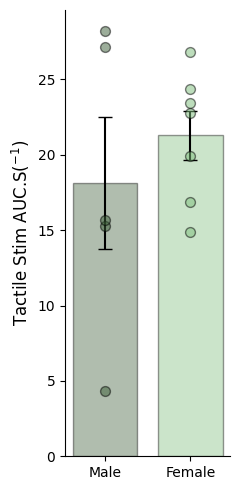

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu, shapiro

# Chemin vers le fichier Excel
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)

# Filtrer les données pour la période "TS" uniquement
df_ts = df_auc_tac[df_auc_tac['Period'] == 'TS']

# Définir les sexes uniques
sexes = df_ts['Sexe'].unique()

# Définir les couleurs pour chaque sexe
colors = {'M': '#3a5c36', 'F': '#7dbd7b'}
border_colors = {'M': 'black', 'F': 'black'}

# Initialiser un dictionnaire pour les statistiques descriptives
statistics = {}

# Test de Shapiro-Wilk pour chaque sexe
for sex in sexes:
    sex_data = df_ts[df_ts['Sexe'] == sex]['AUC_Znorm_persec']
    mean_auc = sex_data.mean()
    sem_auc = sex_data.sem()
    sample_size = len(sex_data)
    
    # Test de Shapiro-Wilk
    stat_shapiro, p_shapiro = shapiro(sex_data)
    
    # Stocker les résultats dans le dictionnaire
    statistics[sex] = {
        'Mean': mean_auc,
        'SEM': sem_auc,
        'Sample Size': sample_size,
        'Shapiro-Wilk Stat': stat_shapiro,
        'Shapiro-Wilk p-value': p_shapiro
    }

# Afficher les statistiques descriptives
for sex, stats in statistics.items():
    print(f"Sex: {sex}")
    print(f"  Mean: {stats['Mean']:.4f}")
    print(f"  SEM: {stats['SEM']:.4f}")
    print(f"  Sample Size: {stats['Sample Size']}")
    print(f"  Shapiro-Wilk Stat: {stats['Shapiro-Wilk Stat']:.4f}")
    print(f"  Shapiro-Wilk p-value: {stats['Shapiro-Wilk p-value']:.4f}")
    print("")

# Extraire les données pour chaque sexe
male_data = df_ts[df_ts['Sexe'] == 'M']['AUC_Znorm_persec']
female_data = df_ts[df_ts['Sexe'] == 'F']['AUC_Znorm_persec']

# Test de Mann-Whitney U
stat, p_value = mannwhitneyu(male_data, female_data, alternative='two-sided')

# Résultats du test de Mann-Whitney U
print(f"Résultats du test de Mann-Whitney U :")
print(f"  Statistique U : {stat}")
print(f"  p-value : {p_value}")

# Initialiser le graphique
plt.figure(figsize=(2.5, 5))

# Tracer les barres pour chaque sexe
bar_width = 0.75
positions = range(len(sexes))
for i, sex in enumerate(sexes):
    sex_data = df_ts[df_ts['Sexe'] == sex]
    mean_auc = sex_data['AUC_Znorm_persec'].mean()
    sem_auc = sex_data['AUC_Znorm_persec'].sem()
    
    # Ajouter une barre
    plt.bar(
        positions[i],
        mean_auc,
        yerr=sem_auc,
        color=colors.get(sex, 'gray'),
        edgecolor=border_colors.get(sex, 'black'),
        width=bar_width,
        capsize=5,
        label='♂' if sex == 'M' else '♀',
        alpha=0.4,
    )
    
    # Ajouter les points pour chaque animal
    x_values = [positions[i]] * len(sex_data)
    y_values = sex_data['AUC_Znorm_persec'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(sex, 'gray'),
        edgecolor=border_colors.get(sex, 'black'),
        alpha=0.5,
        marker='o',
        s=50,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, ['Male', 'Female'])
plt.ylabel(r'Tactile Stim AUC.S($^{-1}$)')

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Appliquer les réglages de style
plt.tight_layout()

# Afficher le graphique
plt.show()


#### 9.2.3. AUC (Trials) --- ATTENTION STAT PAS FAITE


Statistiques pour les : F
TB : 0.5931 ± 0.1237, n = 56
  Shapiro-Wilk : stat =0.8161, p-value = 0.0000
TS : 21.2816 ± 1.1211, n = 56
  Shapiro-Wilk : stat =0.9862, p-value = 0.7695
PTS : 5.1033 ± 0.6708, n = 56
  Shapiro-Wilk : stat =0.9594, p-value = 0.0566

Statistiques pour les : M
TB : 0.4152 ± 0.1022, n = 40
  Shapiro-Wilk : stat =0.8281, p-value = 0.0000
TS : 18.1241 ± 1.6826, n = 40
  Shapiro-Wilk : stat =0.9903, p-value = 0.9780
PTS : 6.1725 ± 1.0670, n = 40
  Shapiro-Wilk : stat =0.9606, p-value = 0.1757


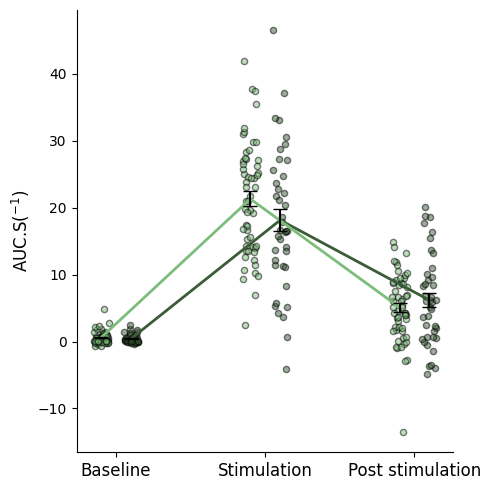

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os

# Chemin vers le fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'

# Charger les données
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Ajouter une colonne 'Condition' si nécessaire
df_auc_tac2['Condition'] = 'Tactile'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac2['Period_type'] = df_auc_tac2['Period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs mis à jour pour correspondre aux valeurs 'M' et 'F'
colors = {'M': '#3a5c36', 'F': '#7dbd7b'}  # Vert pour M et F
border_colors = {'M': 'black', 'F': 'black'}

# Initialiser un dictionnaire pour stocker les statistiques
stats_summary = {}

# Calcul des moyennes, SEM, taille d'échantillon, et test de Shapiro par âge et période
for sex in df_auc_tac2['Sexe'].unique():
    sex_data = df_auc_tac2[df_auc_tac2['Sexe'] == sex]
    stats_summary[sex] = {}
    
    for period in periods:
        period_data = sex_data[sex_data['Period_type'] == period]['AUC_Znorm_persec']
        
        # Calcul des statistiques
        mean_value = period_data.mean()
        sem_value = period_data.sem()
        sample_size = len(period_data)
        
        # Test de Shapiro-Wilk
        if sample_size >= 3:  # Shapiro nécessite au moins 3 valeurs
            shapiro_stat, shapiro_p = shapiro(period_data)
        else:
            shapiro_stat, shapiro_p = None, None  # Pas assez de données pour Shapiro
        
        # Stocker les statistiques
        stats_summary[sex][period] = {
            'mean': mean_value,
            'sem': sem_value,
            'sample_size': sample_size,
            'shapiro_stat': shapiro_stat,
            'shapiro_p': shapiro_p
        }

# Afficher les statistiques
for sex, periods_data in stats_summary.items():
    print(f"\nStatistiques pour les : {sex}")
    for period, stats in periods_data.items():
        print(f"{period} : {stats['mean']:.4f} ± {stats['sem']:.4f}, n = {stats['sample_size']}")
        if stats['shapiro_stat'] is not None:
            print(f"  Shapiro-Wilk : stat ={stats['shapiro_stat']:.4f}, p-value = {stats['shapiro_p']:.4f}")
        else:
            print("  Pas assez de données pour le test de Shapiro-Wilk.")

# Fonction pour tracer les variables en fonction du sexe avec un "jitter"
def plot_variable_sex(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    
    for sex in df['Sexe'].unique():
        sex_data = df[df['Sexe'] == sex]
        
        means[sex] = {period: sex_data[sex_data['Period_type'] == period][variable_name].mean() for period in periods}
        sems[sex] = {period: sex_data[sex_data['Period_type'] == period][variable_name].sem() for period in periods}

        for period in periods:
            x_offset = 0.1 if sex == 'M' else -0.1
            jitter = np.random.uniform(-0.05, 0.05, size=len(sex_data[sex_data['Period_type'] == period]))
            x_values = [positions[period] + x_offset + jitter[i] for i in range(len(sex_data[sex_data['Period_type'] == period]))]
            y_values = sex_data[sex_data['Period_type'] == period][variable_name].values
            
            plt.scatter(x_values, y_values, color=colors.get(sex, 'gray'), edgecolor=border_colors.get(sex, 'black'),
                         linewidth=1, alpha=0.5, marker='o', s=20, zorder=1)
            
            mean_value = means[sex][period]
            sem_value = sems[sex][period]
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='-', color='black', capsize=5, zorder=2)
    
    return means, sems

# Tracer les données pour la condition tactile
plt.figure(figsize=(5, 5))
means_tac2, sems_tac2 = plot_variable_sex(df_auc_tac2, 'AUC_Znorm_persec', 'Tactile', colors, border_colors)


# Ajouter des connexions entre les périodes, avec un ajustement pour chaque sexe
def plot_connections(means, color, positions, periods, x_offsets):
    for i in range(len(periods) - 1):
        # Connexion entre les périodes, mais en fonction de la position réelle des moyennes
        x1 = positions[periods[i]] + x_offsets[periods[i]]
        x2 = positions[periods[i + 1]] + x_offsets[periods[i + 1]]
        y1 = means[periods[i]]
        y2 = means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Définir les décalages pour chaque sexe
x_offsets = {
    'M': {'TB': 0.1, 'TS': 0.1, 'PTS': 0.1},
    'F': {'TB': -0.1, 'TS': -0.1, 'PTS': -0.1}
}

# Ajouter des connexions pour chaque sexe avec les bons décalages
for sex in ['M', 'F']:
    plot_connections(means_tac2[sex], colors[sex], positions, periods, x_offsets[sex])


# Finaliser le graphique
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


##### 9.2.4. AUC of TS period (trials)

Mannwhitney U : Stat = 904.0, p-value : 0.10926534008217226 
Shapiro-Wilk Test (Male): Stat=0.9902850018211057, p-value=0.9780013484698066
Shapiro-Wilk Test (Female): Stat=0.9862108558581385, p-value=0.7694947039314548
Male: 18.124110929668024 ± 1.6825767548108377 
Female : 21.281608014194934 ± 1.1210832334752832


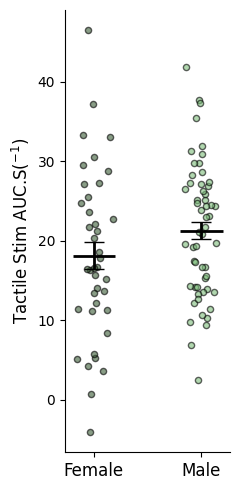

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu, shapiro

# Charger les données à partir du fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Ajouter une colonne 'Period_type' à partir de la colonne 'Period'
df_auc_tac2['Period_type'] = df_auc_tac2['Period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données pour la période 'TS'
df_ts = df_auc_tac2[df_auc_tac2['Period_type'] == 'TS']

# Définir les couleurs pour chaque sexe
colors = {'M': '#3a5c36', 'F': '#7dbd7b'} #4a7c44
border_colors = {'M': 'black', 'F': 'black'}

# Extraire les données pour chaque sexe
male_data = df_ts[df_ts['Sexe'] == 'M']['AUC_Znorm_persec']
female_data = df_ts[df_ts['Sexe'] == 'F']['AUC_Znorm_persec']

# Test de Mann-Whitney U
stat, p_value = mannwhitneyu(male_data, female_data, alternative='two-sided')

# Afficher les résultats du test
print(f"Mannwhitney U : Stat = {stat}, p-value : {p_value} ")

# Test de Shapiro-Wilk pour tester la normalité des données
male_shapiro_stat, male_shapiro_p = shapiro(male_data)
female_shapiro_stat, female_shapiro_p = shapiro(female_data)

# Afficher les résultats du test de normalité
print(f"Shapiro-Wilk Test (Male): Stat={male_shapiro_stat}, p-value={male_shapiro_p}")
print(f"Shapiro-Wilk Test (Female): Stat={female_shapiro_stat}, p-value={female_shapiro_p}")

# Calcul de la moyenne et de l'erreur standard de la moyenne (SEM) pour chaque groupe
male_mean = male_data.mean()
female_mean = female_data.mean()
male_sem = male_data.sem()
female_sem = female_data.sem()

# Affichage des moyennes et des SEM
print(f"Male: {male_mean} ± {male_sem} ")
print(f"Female : {female_mean} ± {female_sem}")

# Initialiser le graphique
plt.figure(figsize=(2.5, 5))

# Ajouter des points avec jitter
jitter_strength = 0.075  # Contrôler l'intensité du jitter

# Points masculins
male_x = np.random.normal(0, jitter_strength, len(male_data))  # Jitter horizontal
plt.scatter(
    male_x, 
    male_data, 
    color=colors['M'], 
    edgecolor=border_colors['M'], 
    alpha=0.6, 
    marker='o', 
    s=20, 
    zorder=0
)

# Points féminins
female_x = np.random.normal(1, jitter_strength, len(female_data))  # Jitter horizontal
plt.scatter(
    female_x, 
    female_data, 
    color=colors['F'], 
    edgecolor=border_colors['F'], 
    alpha=0.6, 
    marker='o', 
    s=20, 
    zorder=0
)

# Tracer la ligne de la moyenne pour chaque sexe
plt.hlines(male_mean, -0.2, 0.2, colors='black', linestyles='solid', linewidth=2)
plt.hlines(female_mean, 0.8, 1.2, colors='black', linestyles='solid', linewidth=2)  

# Ajouter des barres d'erreur pour la SEM pour chaque sexe
plt.errorbar(0, male_mean, yerr=male_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(1, female_mean, yerr=female_sem, color='black', ecolor='black', elinewidth=2, capsize=7)

# Réglages des axes et de la légende
plt.xticks([0, 1], ['Female', 'Male'])
plt.ylabel(r'Tactile Stim AUC.S($^{-1}$)')

# Enlever les bordures du haut et de la droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()
plt.show()


## 9.3. Response rate

##### 9.3.1 Response rate animals

Female condition: Mean = 94.64 ± SEM = 2.53
Male condition: Mean = 82.50 ± SEM = 14.58

Résultats des tests de normalité (Shapiro-Wilk) :
Male: Statistique = 0.6576, p-value = 0.0033
Female: Statistique = 0.6644, p-value = 0.0015
Test de Mann-Whitney : Statistique = 16.5000, p-value = 0.9262
Les taux de réponse des mâles et des femelles ne sont pas significativement différents.


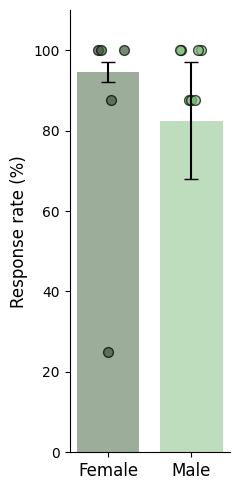

In [20]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import numpy as np

# Chemin du fichier Excel
tac2_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Lecture du fichier Excel
df_tac2 = pd.read_excel(tac2_file_path)

# Séparer les données en fonction du sexe (M = Male, F = Female)
df_male = df_tac2[df_tac2['sexe'] == 'M']
df_female = df_tac2[df_tac2['sexe'] == 'F']

# Calcul du taux de réponse moyen par animal et par sexe
response_data_male = df_male.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_male['response_rate'] *= 100  # En pourcentage

response_data_female = df_female.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_female['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'sexe' pour différencier les groupes
response_data_male['sexe'] = 'Male'
response_data_female['sexe'] = 'Female'

# Combiner les données des deux sexes
combined_data = pd.concat([response_data_male, response_data_female])

# Calculer la moyenne du taux de réponse par animal pour chaque sexe
mean_response_per_animal = combined_data.groupby(['animal', 'sexe'])['response_rate'].mean().reset_index()

# Calcul des moyennes et SEM pour chaque sexe
mean_response_data = mean_response_per_animal.groupby('sexe').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Afficher la moyenne +/- SEM pour chaque sexe
for sexe in mean_response_data['sexe']:
    mean_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0]
    print(f"{sexe} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque sexe
mean_response_male = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Male']['response_rate']
mean_response_female = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Female']['response_rate']

normality_results = {
    "Male": stats.shapiro(mean_response_male),
    "Female": stats.shapiro(mean_response_female)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for sexe, result in normality_results.items():
    print(f"{sexe}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")


# Séparer les taux de réponse
response_male = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Male']['response_rate']
response_female = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Female']['response_rate']

# Effectuer le test de Mann-Whitney
stat, p_value = mannwhitneyu(response_male, response_female)

print(f"Test de Mann-Whitney : Statistique = {stat:.4f}, p-value = {p_value:.4f}")

# Conclusion sur la comparaison statistique
if p_value < 0.05:
    print("Les taux de réponse des mâles et des femelles sont significativement différents.")
else:
    print("Les taux de réponse des mâles et des femelles ne sont pas significativement différents.")


# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par sexe avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['sexe']))

# Barres pour chaque sexe
# Définir les couleurs pour chaque sexe
colors = ['#3a5c36', '#7dbd7b']
for i, sexe in enumerate(mean_response_data['sexe']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0],
        label=f'{sexe} Stim', color=colors[i], alpha = 0.5, capsize=5)

# Ajouter des points individuels pour chaque sexe avec jitter
for sexe, color in zip(['Male', 'Female'], colors):
    individual_data = mean_response_per_animal[mean_response_per_animal['sexe'] == sexe]
    
    # Ajouter un jitter aléatoire pour décaler les points horizontalement
    jitter = 0.12 * np.random.randn(len(individual_data))  # 0.05 est l'amplitude du jitter
    x_offset = x[0] if sexe == 'Male' else x[1]  # Décaler les points sur l'axe x selon le sexe
    
    # Tracer les points avec jitter
    plt.scatter(
        [x_offset + j for j in jitter],  # Ajouter le jitter à chaque position x
        individual_data['response_rate'],
        color=color,
        alpha=0.7,
        edgecolor='black',
        s=50  # Taille des points
    )

# Mise en forme du graphique
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['sexe'])
plt.ylim(0, 110)

# Enlever les bordures du haut et de droite pour le graphique
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()


plt.show()


##### 9.3.1 Response rate trials

Female condition: Mean = 94.64 ± SEM = 3.04
Male condition: Mean = 82.50 ± SEM = 6.08

Résultats des tests de normalité (Shapiro-Wilk) :
Male: Statistique = 0.4615, p-value = 0.0000
Female: Statistique = 0.2371, p-value = 0.0000
Test de Mann-Whitney : Statistique = 984.0000, p-value = 0.0570
Les taux de réponse des mâles et des femelles ne sont pas significativement différents.

Taille des échantillons :
Male : 40
Female : 56


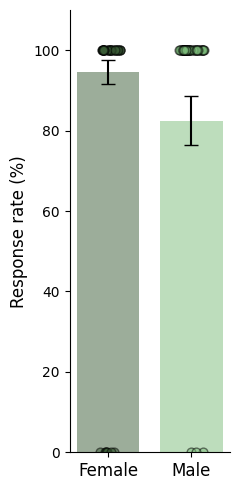

In [6]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import numpy as np

# Chemin du fichier Excel
tac2_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Lecture du fichier Excel
df = pd.read_excel(tac2_file_path)

# Séparer les données en fonction du sexe (M = Male, F = Female)
df_male = df[df['sexe'] == 'M']
df_female = df[df['sexe'] == 'F']

# Calcul du taux de réponse moyen par animal et par sexe
response_data_male = df_male.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_male['response_rate'] *= 100  # En pourcentage

response_data_female = df_female.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_female['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'sexe' pour différencier les groupes
response_data_male['sexe'] = 'Male'
response_data_female['sexe'] = 'Female'

# Combiner les données des deux sexes
combined_data = pd.concat([response_data_male, response_data_female])

# Calcul des moyennes et SEM pour chaque sexe
mean_response_data = combined_data.groupby('sexe').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Afficher la moyenne +/- SEM pour chaque sexe
for sexe in mean_response_data['sexe']:
    mean_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0]
    print(f"{sexe} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque sexe
mean_response_male = combined_data[combined_data['sexe'] == 'Male']['response_rate']
mean_response_female = combined_data[combined_data['sexe'] == 'Female']['response_rate']

normality_results = {
    "Male": stats.shapiro(mean_response_male),
    "Female": stats.shapiro(mean_response_female)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for sexe, result in normality_results.items():
    print(f"{sexe}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")


# Séparer les taux de réponse
response_male = combined_data[combined_data['sexe'] == 'Male']['response_rate']
response_female = combined_data[combined_data['sexe'] == 'Female']['response_rate']

# Effectuer le test de Mann-Whitney
stat, p_value = mannwhitneyu(response_male, response_female)

print(f"Test de Mann-Whitney : Statistique = {stat:.4f}, p-value = {p_value:.4f}")

# Conclusion sur la comparaison statistique
if p_value < 0.05:
    print("Les taux de réponse des mâles et des femelles sont significativement différents.")
else:
    print("Les taux de réponse des mâles et des femelles ne sont pas significativement différents.")


# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par sexe avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['sexe']))

# Barres pour chaque sexe

# Définir les couleurs pour chaque sexe
colors = ['#3a5c36', '#7dbd7b']
for i, sexe in enumerate(mean_response_data['sexe']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0],
        label=f'{sexe} Stim', color=colors[i], alpha = 0.5, capsize=5)

# Ajouter des points individuels pour chaque sexe avec jitter
for sexe, color in zip(['Male', 'Female'], colors):
    individual_data = combined_data[combined_data['sexe'] == sexe]
    
    # Générer du jitter
    jitter = np.random.uniform(-0.15, 0.15, size=len(individual_data))  # Décalage aléatoire pour éviter la superposition
    
    # Position X ajustée avec jitter
    x_position = x[0] if sexe == 'Male' else x[1]
    x_values = x_position + jitter  # Ajouter le jitter à la position
    
    # Scatter plot avec jitter
    plt.scatter(
        x_values,
        individual_data['response_rate'],
        color=color,
        alpha=0.5,
        edgecolor='black',
        s=40  # Taille des points
    )

# Vérification des tailles d'échantillons
sample_size_male = len(mean_response_male)  # Taille de l'échantillon pour Male
sample_size_female = len(mean_response_female)    # Taille de l'échantillon pour Female

print("\nTaille des échantillons :")
print(f"Male : {sample_size_male}")
print(f"Female : {sample_size_female}")

# Mise en forme du graphique
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['sexe'])
plt.ylim(0, 110)

# Enlever les bordures du haut et de droite pour le graphique
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

plt.show()


#

#

# 10. Age effect

### 10.1. PSTC

Nombre de P6 : 3
Nombre de P7 : 4
Nombre de P8 : 5
La valeur maximale de Znorm pour le sexe P6 (0-2.1s) est : 3.742142067704547
La valeur maximale de Znorm pour le sexe P7 (0-2.1s) est : 3.2558010977367378
La valeur maximale de Znorm pour le sexe P8 (0-2.1s) est : 1.8207993506345808


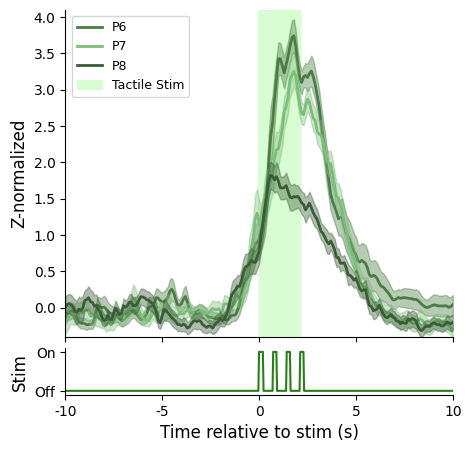

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Chemin vers le fichier Excel
file_path_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Zscore_classic_tactile2_stim.xlsx'

# Lire le fichier Excel
df_tac2 = pd.read_excel(file_path_tac2)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_tac2['time_sec'] = df_tac2['Stim_Time'] / 1000

# Extraire le type de période (TB, TS, PTS)
df_tac2['Period_type'] = df_tac2['period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']

# Compter le nombre d'animaux par age
if 'animal' in df_tac2.columns:
    animal_count = df_tac2[['animal', 'age']].drop_duplicates().groupby('age').size()
    count_p6 = animal_count.get('P6', 0)  # Nombre d'animaux mâles
    count_p7 = animal_count.get('P7', 0)  # Nombre d'animaux femelles
    count_p8 = animal_count.get('P8', 0)  # Nombre d'animaux femelles
    print(f"Nombre de P6 : {count_p6}")
    print(f"Nombre de P7 : {count_p7}")
    print(f"Nombre de P8 : {count_p8}")
else:
    print("La colonne 'animal' n'existe pas dans le fichier.")

# Grouper par 'age' et 'time_sec', puis calculer les moyennes et erreurs standards
grouped = df_tac2.groupby(['age', 'time_sec','Period_type']).agg(
    Mean_Zscore_norm=('Znorm', 'mean'),
    SEM_Zscore_norm=('Znorm', 'sem'),
).reset_index()

age_colors = {
    'P6': {'mean': '#4a7c44', 'sem': '#4a7c44'},  # Bleu-vert clair
    'P7': {'mean': '#7dbd7b', 'sem': '#7dbd7b'},  # Vert plus sombre
    'P8': {'mean': '#3a5c36', 'sem': '#3a5c36'}   # Teinte plus sombre et intense
}

# Créer la figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Calculer les limites réelles pour l'axe y
y_min = grouped['Mean_Zscore_norm'].min()
y_max = grouped['Mean_Zscore_norm'].max()


# Tracer les courbes pour chaque age
for age, color in age_colors.items():
    age_data = grouped[grouped['age'] == age]

    # Tracer la courbe moyenne pour le Z-score
    ax1.plot(
        age_data['time_sec'], age_data['Mean_Zscore_norm'],
        color=color['mean'], linewidth=2, label=f"{age}"
    )

    # Ajouter une zone ombrée pour le SEM
    ax1.fill_between(
        age_data['time_sec'],
        age_data['Mean_Zscore_norm'] - age_data['SEM_Zscore_norm'],
        age_data['Mean_Zscore_norm'] + age_data['SEM_Zscore_norm'],
        color=color['sem'], alpha=0.4, zorder=2
    )


# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in grouped.iterrows():
    if row['Period_type'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax1.fill_between(
            grouped['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(grouped['time_sec'] >= start_time) & (grouped['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False


# Ajouter une seule entrée de légende stim
ax1.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)


# Remplir la zone au-dessus de l'ombre de la SEM (jusqu'au haut du graphique)
ax1.fill_between(
    grouped['time_sec'], 
    grouped['Mean_Zscore_norm'] + grouped['SEM_Zscore_norm'], 
    y_max +5,  # Limite supérieure réelle du graphique
    where=(grouped['time_sec'] >= start_time) & (grouped['time_sec'] <= end_time),
    color=color_ts, zorder=0
)

# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(grouped))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in grouped.iterrows():
    if row['Period_type'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False


# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1.5)

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized')
ax1.legend(loc="upper left")

# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.4, 4.1)
ax1.set_xlim(-10, 10)

ax1.set_xticks([-10, -5, 0, 5, 10])
ax1.set_xticklabels("")
ax1.set_xlim(-10, 10)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])
ax2.set_xlim(-10, 10)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

# Filtrer les données pour 'time_sec' entre 0 et 3.9
filtered_data = grouped[(grouped['time_sec'] >= 0) & (grouped['time_sec'] <= 2.1)]

# Trouver la valeur maximale de Z-score_norm pour chaque sexe
max_values_by_age = filtered_data.groupby('age')['Mean_Zscore_norm'].max()

# Afficher les valeurs maximales pour chaque sexe
for age, max_value in max_values_by_age.items():
    print(f"La valeur maximale de Znorm pour le sexe {age} (0-2.1s) est : {max_value}")

#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout


# Afficher le graphique
plt.show()


## 10.2. AUC age

#### 10.2.1. AUC (animals)


Statistiques pour l'âge P7:
TB: Mean ± SEM = 0.4571 ± 0.1725, N = 4, Shapiro test: Stat = 0.9180, p-value = 0.5260
TS: Mean ± SEM = 21.5804 ± 2.5511, N = 4, Shapiro test: Stat = 0.9679, p-value = 0.8284
PTS: Mean ± SEM = 6.6347 ± 1.5529, N = 4, Shapiro test: Stat = 0.8987, p-value = 0.4247

Statistiques pour l'âge P8:
TB: Mean ± SEM = 0.5392 ± 0.3009, N = 5, Shapiro test: Stat = 0.7227, p-value = 0.0163
TS: Mean ± SEM = 14.8975 ± 2.9848, N = 5, Shapiro test: Stat = 0.9111, p-value = 0.4741
PTS: Mean ± SEM = 2.7579 ± 0.8725, N = 5, Shapiro test: Stat = 0.9794, p-value = 0.9316

Statistiques pour l'âge P6:
TB: Mean ± SEM = 0.5679 ± 0.3619, N = 3, Shapiro test: Stat = 0.9265, p-value = 0.4755
TS: Mean ± SEM = 26.2608 ± 1.4520, N = 3, Shapiro test: Stat = 0.9014, p-value = 0.3898
PTS: Mean ± SEM = 8.7523 ± 3.0417, N = 3, Shapiro test: Stat = 0.8210, p-value = 0.1658


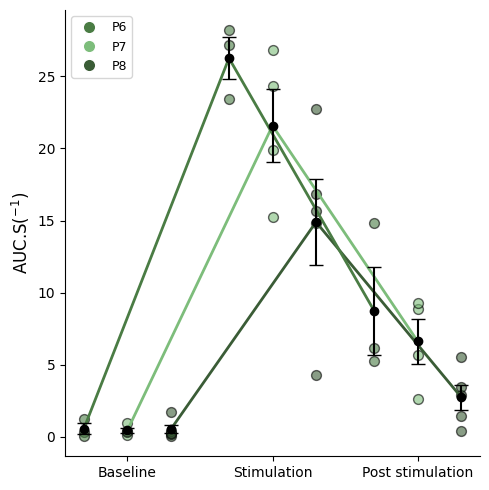

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os

# Chemin vers le fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs mis à jour pour correspondre aux valeurs 'P6', 'P7' et 'P8'
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Fonction pour calculer les statistiques et faire un test de Shapiro
def calculate_stats_and_shapiro(df, variable_name, periods):
    stats = {}
    shapiro_results = {}
    
    for age in df['Age'].unique():
        age_data = df[df['Age'] == age]
        stats[age] = {}
        shapiro_results[age] = {}
        
        for period in periods:
            period_data = age_data[age_data['Period'] == period][variable_name]
            n = len(period_data)  # Taille de l'échantillon
            mean_value = period_data.mean()
            sem_value = period_data.sem()
            
            # Stocker les statistiques
            stats[age][period] = (mean_value, sem_value, n)
            
            # Test de normalité de Shapiro
            stat, p_value = shapiro(period_data)
            shapiro_results[age][period] = (stat, p_value)
    
    return stats, shapiro_results

# Calcul des statistiques et tests de Shapiro
stats, shapiro_results = calculate_stats_and_shapiro(df_auc_tac2, 'AUC_Znorm_persec', periods)

# Affichage des résultats : moyenne, SEM, taille de l'échantillon et test de Shapiro
for age in stats.keys():
    print(f"\nStatistiques pour l'âge {age}:")
    for period in periods:
        mean, sem, n = stats[age][period]
        shapiro_stat, shapiro_p_value = shapiro_results[age][period]
        print(f"{period}: Mean ± SEM = {mean:.4f} ± {sem:.4f}, N = {n}, Shapiro test: Stat = {shapiro_stat:.4f}, p-value = {shapiro_p_value:.4f}")

# Fonction pour tracer les variables en fonction de l'Age
def plot_variable_age(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    
    # Calcul des moyennes et SEM par Age
    for age in df['Age'].unique():
        age_data = df[df['Age'] == age]
        
        means[age] = {period: age_data[age_data['Period'] == period][variable_name].mean() for period in periods}
        sems[age] = {period: age_data[age_data['Period'] == period][variable_name].sem() for period in periods}

        # Tracer les données de chaque Age avec décalage sur l'axe x
        for period in periods:
            x_offset = 0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0)  # Décalage spécifique pour chaque âge
            x_values = [positions[period] + x_offset] * len(age_data[age_data['Period'] == period])
            y_values = age_data[age_data['Period'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(age, 'gray'), edgecolor=border_colors.get(age, 'black'),
                         linewidth=1, alpha=0.6, marker='o', s=50, zorder=1)
            
            mean_value = means[age][period]
            sem_value = sems[age][period]
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    
    return means, sems

# Exemple d'appel pour afficher les graphiques pour la condition 'Tactile' et la variable 'AUC_Znorm_persec'
plt.figure(figsize=(5, 5))
means_age, sems_age = plot_variable_age(df_auc_tac2, 'AUC_Znorm_persec', 'Tactile', colors, border_colors)

# Fonction pour afficher les connexions entre les moyennes
def plot_connections(means, age, variable_name, color):
    for i in range(len(periods) - 1):
        # Appliquer un décalage en fonction de l'âge pour chaque connexion
        x1 = positions[periods[i]] + (0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0))
        x2 = positions[periods[i + 1]] + (0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0))
        y1, y2 = means[age][periods[i]], means[age][periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Ensuite, appelez cette fonction pour chaque Age
for age in df_auc_tac2['Age'].unique():
    plot_connections(means_age, age, 'AUC_Znorm_persec', colors[age])

# Ajouter des résultats de tests statistiques, si nécessaires
y_offset = 4.5  # Décalage vertical pour les barres de significativité
spacing_between_bars = 2  # Espacement entre les barres de significativité

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')

# Ajouter la légende en haut à gauche avec les symboles des Ages
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P6'], markersize=9, label='P6'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P7'], markersize=9, label='P7'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P8'], markersize=9, label='P8')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()
plt.show()


#### 10.2.2. AUC TS (animals)

Statistique H : 6.271794871794874
p-value : 0.04346073310060689
          P6        P7        P8
P6  1.000000  0.678313  0.039281
P7  0.678313  1.000000  0.557469
P8  0.039281  0.557469  1.000000
Age P6: Mean ± SEM = 26.2608 ± 1.4520, Sample size = 3
Shapiro-Wilk Test for Age P6: Stat = 0.9014, p-value = 0.3898
Age P7: Mean ± SEM = 21.5804 ± 2.5511, Sample size = 4
Shapiro-Wilk Test for Age P7: Stat = 0.9679, p-value = 0.8284
Age P8: Mean ± SEM = 14.8975 ± 2.9848, Sample size = 5
Shapiro-Wilk Test for Age P8: Stat = 0.9111, p-value = 0.4741


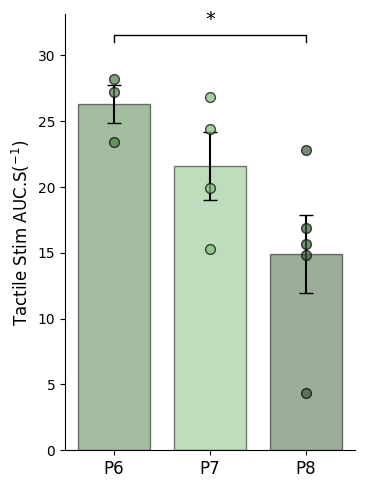

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import kruskal, shapiro
from scikit_posthocs import posthoc_dunn

# Chemin vers le fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Filtrer les données pour la période "TS" uniquement
df_ts = df_auc_tac2[df_auc_tac2['Period'] == 'TS']

# Définir les âges uniques
ages = sorted(df_ts['Age'].unique())

# Définir les couleurs pour chaque âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

# Extraire les données pour chaque groupe d'âge
data_by_age = [df_ts[df_ts['Age'] == age]['AUC_Znorm_persec'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df_ts, val_col='AUC_Znorm_persec', group_col='Age', p_adjust='bonferroni')

# Résultats
print(posthoc)

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque âge
bar_width = 0.75
positions = range(len(ages))
for i, age in enumerate(ages):
    age_data = df_ts[df_ts['Age'] == age]
    mean_auc = age_data['AUC_Znorm_persec'].mean()
    sem_auc = age_data['AUC_Znorm_persec'].sem()
    sample_size = len(age_data)
    
    # Afficher la moyenne, SEM et taille de l'échantillon
    print(f"Age {age}: Mean ± SEM = {mean_auc:.4f} ± {sem_auc:.4f}, Sample size = {sample_size}")

    # Test de Shapiro-Wilk pour la normalité
    stat_shapiro, p_shapiro = shapiro(age_data['AUC_Znorm_persec'])
    print(f"Shapiro-Wilk Test for Age {age}: Stat = {stat_shapiro:.4f}, p-value = {p_shapiro:.4f}")

    # Ajouter une barre
    plt.bar(
        positions[i],
        mean_auc,
        yerr=sem_auc,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points pour chaque animal
    x_values = [positions[i]] * len(age_data)
    y_values = age_data['AUC_Znorm_persec'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.7,
        marker='o',
        s=50,
        zorder=2,
    )


# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les âges
y_offset = 27  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 4  # Espacement entre chaque barre de significativité

if posthoc is not None:
    for i, age_1 in enumerate(ages):
        for j, age_2 in enumerate(ages):
            if i < j:  # Comparer uniquement les paires distinctes
                p_val = posthoc.loc[age_1, age_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = i 
                    x2 = j
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des âges
                    significance_y_position = y_offset + i + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel(r'Tactile Stim AUC.S($^{-1}$)')

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Appliquer les réglages de style
plt.tight_layout()

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Afficher le graphique
plt.show()


#### 10.2.3. AUC (Trials) --- ATTENTION STAT PAS FAITE

P6-TB : 0.5679 ± 0.1413, n=24
Shapiro-Wilk : stat = 0.8927, p-value =0.0151
----------------------------------------
P6-TS : 26.2608 ± 1.6121, n=24
Shapiro-Wilk : stat = 0.9805, p-value =0.9050
----------------------------------------
P6-PTS : 8.7523 ± 1.2836, n=24
Shapiro-Wilk : stat = 0.9620, p-value =0.4807
----------------------------------------
P7-TB : 0.4571 ± 0.1090, n=32
Shapiro-Wilk : stat = 0.9533, p-value =0.1786
----------------------------------------
P7-TS : 21.5804 ± 1.5878, n=32
Shapiro-Wilk : stat = 0.9912, p-value =0.9947
----------------------------------------
P7-PTS : 6.6347 ± 1.0057, n=32
Shapiro-Wilk : stat = 0.9116, p-value =0.0124
----------------------------------------
P8-TB : 0.5392 ± 0.1624, n=40
Shapiro-Wilk : stat = 0.7319, p-value =0.0000
----------------------------------------
P8-TS : 14.8975 ± 1.2716, n=40
Shapiro-Wilk : stat = 0.9597, p-value =0.1636
----------------------------------------
P8-PTS : 2.7579 ± 0.6603, n=40
Shapiro-Wilk : stat = 0.9735

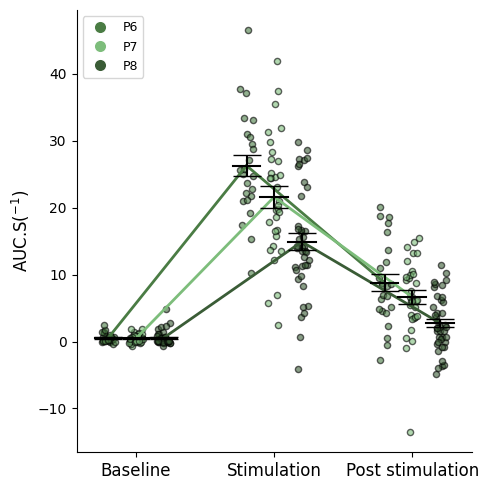

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os

# Chemin vers le fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'

# Charger les données
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Ajouter une colonne 'Condition' si nécessaire
df_auc_tac2['Condition'] = 'Tactile'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac2['Period_type'] = df_auc_tac2['Period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Définir les couleurs pour chaque âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Fonction pour tracer les variables avec un décalage et jitter améliorés
def plot_variable_age(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    sample_sizes = {}
    shapiro_results = {}
    
    # Calcul des moyennes, SEM et taille d'échantillon par Age
    for age in df['Age'].unique():
        age_data = df[df['Age'] == age]
        
        means[age] = {period: age_data[age_data['Period_type'] == period][variable_name].mean() for period in periods}
        sems[age] = {period: age_data[age_data['Period_type'] == period][variable_name].sem() for period in periods}
        sample_sizes[age] = {period: age_data[age_data['Period_type'] == period][variable_name].count() for period in periods}

        # Test de Shapiro pour chaque groupe (âge et période)
        shapiro_results[age] = {}
        for period in periods:
            period_data = age_data[age_data['Period_type'] == period][variable_name]
            stat, p_value = shapiro(period_data)
            shapiro_results[age][period] = {'stat': stat, 'p_value': p_value}


        # Définir un décalage fixe pour chaque âge
        age_offsets = {'P6': -0.2, 'P7': 0.0, 'P8': 0.2}
        x_offset = age_offsets.get(age, 0)

        # Tracer les données de chaque Age avec un décalage sur l'axe x
        for period in periods:
            # Ajouter un jitter limité pour éviter le chevauchement
            jitter = np.random.uniform(-0.05, 0.05, size=len(age_data[age_data['Period_type'] == period]))
            x_values = [positions[period] + x_offset + jitter[i] for i in range(len(age_data[age_data['Period_type'] == period]))]
            y_values = age_data[age_data['Period_type'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(age, 'gray'), edgecolor=border_colors.get(age, 'black'),
                         linewidth=1, alpha=0.6, marker='o', s=20, zorder=1)

            # Tracer la moyenne et SEM pour chaque âge et période
            mean_value = means[age][period]
            sem_value = sems[age][period]

            # Tracer la moyenne avec une barre horizontale (petite ligne centrale)
            plt.plot(
                [positions[period] + x_offset - 0.1, positions[period] + x_offset + 0.1],
                [mean_value, mean_value],
                color='black', linewidth=1.5, zorder=3
            )

            # Tracer les barres d'erreur verticales (SEM)
            plt.errorbar(
                positions[period] + x_offset, mean_value,
                yerr=sem_value, color='black', capsize=10, linewidth=1.5, zorder=3
            )

            # Afficher les valeurs de mean ± SEM et la taille de l'échantillon
            print(f"{age}-{period} : {mean_value:.4f} ± {sem_value:.4f}, n={sample_sizes[age][period]}")
            print(f"Shapiro-Wilk : stat = {shapiro_results[age][period]['stat']:.4f}, p-value ={shapiro_results[age][period]['p_value']:.4f}")
            print('-' * 40)


    return means, sems, sample_sizes, shapiro_results

# Appliquer la fonction pour tracer
plt.figure(figsize=(5, 5))
means_tac2, sems_tac2, sample_sizes_tac2, shapiro_results_tac2 = plot_variable_age(df_auc_tac2, 'AUC_Znorm_persec', 'Tactile', colors, border_colors)

# Fonction pour tracer les connexions entre les moyennes
def plot_connections(means, color, positions, periods, x_offsets, zorder):
    """
    Trace des connexions entre les moyennes des périodes pour un âge donné.
    """
    for i in range(len(periods) - 1):
        # Obtenir les périodes actuelles
        period1 = periods[i]
        period2 = periods[i + 1]

        # Calcul des positions x et y pour les connexions
        x1 = positions[period1] + x_offsets.get(period1, 0)
        x2 = positions[period2] + x_offsets.get(period2, 0)
        y1 = means.get(period1, np.nan)
        y2 = means.get(period2, np.nan)

        # Vérifier que les moyennes ne sont pas manquantes
        if not np.isnan(y1) and not np.isnan(y2):
            plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Définir les décalages pour chaque âge et chaque période
x_offsets = {
    'P6': {'TB': -0.2, 'TS': -0.2, 'PTS': -0.2},
    'P7': {'TB': 0.0, 'TS': 0.0, 'PTS': 0.0},
    'P8': {'TB': 0.2, 'TS': 0.2, 'PTS': 0.2}
}

# Ajouter des connexions pour chaque âge
for age in ['P6', 'P7', 'P8']:
    age_offsets = x_offsets[age]
    plot_connections(means_tac2[age], colors[age], positions, periods, age_offsets, zorder=2)

# Finaliser le graphique
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajouter une légende
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P6'], markersize=9, label='P6'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P7'], markersize=9, label='P7'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P8'], markersize=9, label='P8')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

plt.show()


##### 10.2.4. AUC of TS period (trials)

kruskal Stat H : 23.299860395189
p-value : 8.719660994344179e-06
          P6        P7        P8
P6  1.000000  0.227544  0.000009
P7  0.227544  1.000000  0.006825
P8  0.000009  0.006825  1.000000
Mean P6: 26.260819460006644 ± 1.6121380468030875, n = 24
Mean P7: 21.580431545935454 ± 1.5877734558907384, n = 32
Mean P8: 14.897525236788585 ± 1.2716443605657664, n = 40
Shapiro-Wilk Test pour P6: Stat=0.9805066433296085, p-value=0.9050126195352073
Shapiro-Wilk Test pour P7: Stat=0.9912339905554907, p-value=0.994654037071322
Shapiro-Wilk Test pour P8: Stat=0.9596982010180936, p-value=0.16356349679302012


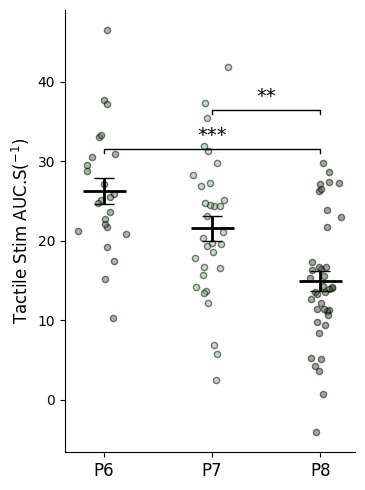

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import kruskal, shapiro
from scikit_posthocs import posthoc_dunn


# Charger les données à partir du fichier Excel
file_path_auc_tactile = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'
df_auc_tac2 = pd.read_excel(file_path_auc_tactile)

# Ajouter une colonne 'Period_type' à partir de la colonne 'Period'
df_auc_tac2['Period_type'] = df_auc_tac2['Period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données pour la période 'TS'
df_ts_trials = df_auc_tac2[df_auc_tac2['Period_type'] == 'TS']

# Définir les couleurs pour chaque âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Extraire les données pour chaque sexe
P6_data = df_ts_trials[df_ts_trials['Age'] == 'P6']['AUC_Znorm_persec']
P7_data = df_ts_trials[df_ts_trials['Age'] == 'P7']['AUC_Znorm_persec']
P8_data = df_ts_trials[df_ts_trials['Age'] == 'P8']['AUC_Znorm_persec']


# Définir les âges uniques
ages = sorted(df_ts_trials['Age'].unique())

# Extraire les données pour chaque groupe d'âge
data_by_age = [df_ts_trials[df_ts_trials['Age'] == age]['AUC_Znorm_persec'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats Kruskal-Wallis
print(f"kruskal Stat H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df_ts_trials, val_col='AUC_Znorm_persec', group_col='Age', p_adjust='bonferroni')

# Résultats Dunn
print(posthoc)


# Calcul de la moyenne et de l'erreur standard de la moyenne (SEM) pour chaque groupe
P6_mean = P6_data.mean()
P7_mean = P7_data.mean()
P8_mean = P8_data.mean()

P6_sem = P6_data.sem()
P7_sem = P7_data.sem()
P8_sem = P8_data.sem()


# Taille des échantillons pour chaque groupe d'âge
P6_sample_size = len(P6_data)
P7_sample_size = len(P7_data)
P8_sample_size = len(P8_data)

# Affichage des moyennes et des SEM
print(f"Mean P6: {P6_mean} ± {P6_sem}, n = {P6_sample_size}")
print(f"Mean P7: {P7_mean} ± {P7_sem}, n = {P7_sample_size}")
print(f"Mean P8: {P8_mean} ± {P8_sem}, n = {P8_sample_size}")


# Test de normalité de Shapiro-Wilk pour chaque groupe d'âge
shapiro_p6_stat, shapiro_p6_pval = shapiro(P6_data)
shapiro_p7_stat, shapiro_p7_pval = shapiro(P7_data)
shapiro_p8_stat, shapiro_p8_pval = shapiro(P8_data)

# Affichage des résultats du test de Shapiro
print(f"Shapiro-Wilk Test pour P6: Stat={shapiro_p6_stat}, p-value={shapiro_p6_pval}")
print(f"Shapiro-Wilk Test pour P7: Stat={shapiro_p7_stat}, p-value={shapiro_p7_pval}")
print(f"Shapiro-Wilk Test pour P8: Stat={shapiro_p8_stat}, p-value={shapiro_p8_pval}")


# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Ajouter des points avec jitter
jitter_strength = 0.075  # Contrôler l'intensité du jitter

# Points masculins
p6_x = np.random.normal(0, jitter_strength, len(P6_data))  # Jitter horizontal
plt.scatter(
    p6_x, 
    P6_data, 
    color=colors['P6'], 
    edgecolor=border_colors['P6'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

p7_x = np.random.normal(1, jitter_strength, len(P7_data))  # Jitter horizontal
plt.scatter(
    p7_x, 
    P7_data, 
    color=colors['P7'], 
    edgecolor=border_colors['P7'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

p8_x = np.random.normal(2, jitter_strength, len(P8_data))  # Jitter horizontal
plt.scatter(
    p8_x, 
    P8_data, 
    color=colors['P8'], 
    edgecolor=border_colors['P8'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)


# Tracer la ligne de la moyenne pour chaque sexe
plt.hlines(P6_mean, -0.2, 0.2, colors='black', linestyles='solid', linewidth=2)
plt.hlines(P7_mean, 0.8, 1.2, colors='black', linestyles='solid', linewidth=2)  
plt.hlines(P8_mean, 1.8, 2.2, colors='black', linestyles='solid', linewidth=2)  


# Ajouter des barres d'erreur pour la SEM pour chaque sexe
plt.errorbar(0, P6_mean, yerr=P6_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(1, P7_mean, yerr=P7_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(2, P8_mean, yerr=P8_sem, color='black', ecolor='black', elinewidth=2, capsize=7)


# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les âges
y_offset = 27  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 4  # Espacement entre chaque barre de significativité

if posthoc is not None:
    for i, age_1 in enumerate(ages):
        for j, age_2 in enumerate(ages):
            if i < j:  # Comparer uniquement les paires distinctes
                p_val = posthoc.loc[age_1, age_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = i 
                    x2 = j
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des âges
                    significance_y_position = y_offset + i + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Réglages des axes et de la légende
plt.xticks([0, 1, 2], ['P6', 'P7', 'P8'])
plt.ylabel(r'Tactile Stim AUC.S($^{-1}$)')

# Enlever les bordures du haut et de la droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Affichage du graphique
plt.tight_layout()

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.show()


### 10.3. Response rate

##### 10.3.1. Response rate (animals)

Statistique H : 2.7450000000000054
p-value : 0.25347248557684277
          P6      P7        P8
P6  1.000000  0.7646  0.299632
P7  0.764600  1.0000  1.000000
P8  0.299632  1.0000  1.000000
P6 - Mean: 100.00 ± SEM: 0.00, n = 3
Shapiro-Wilk Test for P6: Stat=1.0000, p-value=1.0000
Les données pour P6 suivent une distribution normale.
P7 - Mean: 93.75 ± SEM: 3.61, n = 4
Shapiro-Wilk Test for P7: Stat=0.7286, p-value=0.0239
Les données pour P7 ne suivent pas une distribution normale.
P8 - Mean: 80.00 ± SEM: 14.03, n = 5
Shapiro-Wilk Test for P8: Stat=0.7098, p-value=0.0121
Les données pour P8 ne suivent pas une distribution normale.


c:\Users\zayan\Anaconda\envs\calcium1p\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


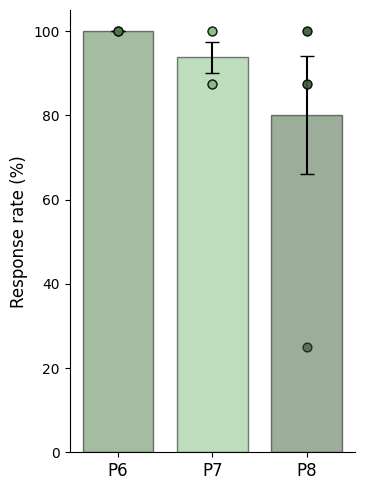

In [67]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, shapiro
from scikit_posthocs import posthoc_dunn

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Charger les données
df_tac2 = pd.read_excel(file_path)

# Séparer les données par groupe d'âge
df_p6 = df_tac2[df_tac2['age'] == 'P6']
df_p7 = df_tac2[df_tac2['age'] == 'P7']
df_p8 = df_tac2[df_tac2['age'] == 'P8']

# Calcul du taux de réponse moyen par animal et par âge
response_data_p6 = df_p6.groupby(['animal', 'age'])['response_rate'].mean().reset_index()
response_data_p7 = df_p7.groupby(['animal', 'age'])['response_rate'].mean().reset_index()
response_data_p8 = df_p8.groupby(['animal', 'age'])['response_rate'].mean().reset_index()

# Combiner les données des trois groupes d'âge
combined_data = pd.concat([response_data_p6, response_data_p7, response_data_p8])

# Convertir le taux de réponse en pourcentage
combined_data['response_rate'] = combined_data['response_rate'] * 100

# Définir les âges uniques
ages = sorted(combined_data['age'].unique())

# Définir les couleurs pour chaque groupe d'âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

# Extraire les données pour chaque groupe d'âge
data_by_age = [combined_data[combined_data['age'] == age]['response_rate'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(combined_data, val_col='response_rate', group_col='age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque groupe d'âge
bar_width = 0.75
positions = range(len(ages))

for i, age in enumerate(ages):
    age_data = combined_data[combined_data['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()

    # Ajouter une barre avec l'intervalle de confiance (SEM)
    plt.bar(
        positions[i],
        mean_response,
        yerr=sem_response,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points individuels pour chaque animal
    x_values = [positions[i]] * len(age_data)
    y_values = age_data['response_rate'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.7,
        marker='o',
        s=40,
        zorder=2,
    )

    # Calculer et afficher la moyenne ± SEM et la taille de l'échantillon
    sample_size = len(age_data)
    print(f"{age} - Mean: {mean_response:.2f} ± SEM: {sem_response:.2f}, n = {sample_size}")

    # Test de normalité de Shapiro-Wilk pour chaque groupe d'âge
    stat, p_val = shapiro(age_data['response_rate'])
    print(f"Shapiro-Wilk Test for {age}: Stat={stat:.4f}, p-value={p_val:.4f}")
    if p_val < 0.05:
        print(f"Les données pour {age} ne suivent pas une distribution normale.")
    else:
        print(f"Les données pour {age} suivent une distribution normale.")

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel('Response rate (%)')

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Appliquer les réglages de style
plt.tight_layout()

# Afficher le graphique
plt.show()


##### 10.3.2. Response rate (trials)

Statistique H : 7.24651162790685
p-value : 0.026695618879402572
          P6        P7        P8
P6  1.000000  1.000000  0.034961
P7  1.000000  1.000000  0.177099
P8  0.034961  0.177099  1.000000


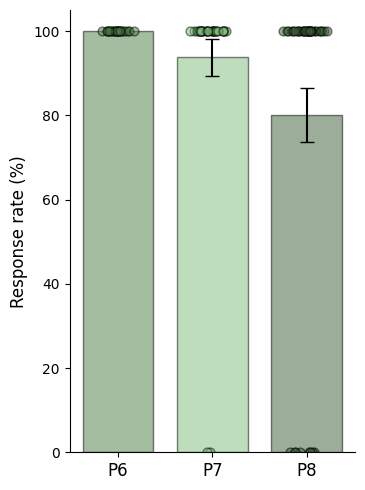

In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Charger les données
df = pd.read_excel(file_path)

# Convertir le taux de réponse en pourcentage
df['response_rate'] = df['response_rate'] * 100

# Filtrer les données par groupe d'âge
ages = sorted(df['age'].unique())  # Identifier les groupes d'âge uniques

# Définir les couleurs pour chaque groupe d'âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

# Test de Kruskal-Wallis
data_by_age = [df[df['age'] == age]['response_rate'] for age in ages]
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df, val_col='response_rate', group_col='age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque groupe d'âge avec les points individuels
bar_width = 0.75
positions = range(len(ages))
jitter_strength = 0.1  # Contrôle l'intensité du jitter

for i, age in enumerate(ages):
    age_data = df[df['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()

    # Ajouter une barre avec l'intervalle de confiance (SEM)
    plt.bar(
        positions[i],
        mean_response,
        yerr=sem_response,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points individuels pour chaque animal avec jitter
    jitter = np.random.normal(0, jitter_strength, size=len(age_data))
    x_values = np.array([positions[i]] * len(age_data)) + jitter
    y_values = age_data['response_rate'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.5,
        marker='o',
        s=40,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel('Response rate (%)')

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

# Afficher le graphique
plt.show()


Statistique H : 7.2465
p-value : 0.0267
          P6        P7        P8
P6  1.000000  1.000000  0.034961
P7  1.000000  1.000000  0.177099
P8  0.034961  0.177099  1.000000
Shapiro-Wilk Test for P6: Stat=1.0000, p-value=1.0000
Les données pour P6 suivent une distribution normale.
Shapiro-Wilk Test for P7: Stat=0.2645, p-value=0.0000
Les données pour P7 ne suivent pas une distribution normale.
Shapiro-Wilk Test for P8: Stat=0.4909, p-value=0.0000
Les données pour P8 ne suivent pas une distribution normale.
Age P6: Mean = 100.00, SEM = 0.00, n = 24
Age P7: Mean = 93.75, SEM = 4.35, n = 32
Age P8: Mean = 80.00, SEM = 6.41, n = 40


c:\Users\zayan\Anaconda\envs\calcium1p\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


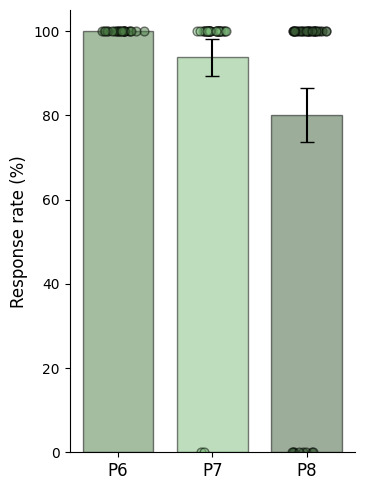

In [70]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal, shapiro
from scikit_posthocs import posthoc_dunn

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Charger les données
df = pd.read_excel(file_path)

# Convertir le taux de réponse en pourcentage
df['response_rate'] = df['response_rate'] * 100

# Filtrer les données par groupe d'âge
ages = sorted(df['age'].unique())  # Identifier les groupes d'âge uniques

# Définir les couleurs pour chaque groupe d'âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

# Test de Kruskal-Wallis
data_by_age = [df[df['age'] == age]['response_rate'] for age in ages]
stat, p_value = kruskal(*data_by_age)

# Résultats du test de Kruskal-Wallis
print(f"Statistique H : {stat:.4f}")
print(f"p-value : {p_value:.4f}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df, val_col='response_rate', group_col='age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Test de normalité de Shapiro-Wilk pour chaque groupe d'âge
for age in ages:
    age_data = df[df['age'] == age]['response_rate']
    stat, p_val = shapiro(age_data)
    print(f"Shapiro-Wilk Test for {age}: Stat={stat:.4f}, p-value={p_val:.4f}")
    if p_val < 0.05:
        print(f"Les données pour {age} ne suivent pas une distribution normale.")
    else:
        print(f"Les données pour {age} suivent une distribution normale.")

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque groupe d'âge avec les points individuels
bar_width = 0.75
positions = range(len(ages))
jitter_strength = 0.1  # Contrôle l'intensité du jitter

for i, age in enumerate(ages):
    age_data = df[df['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()
    n = len(age_data)  # Taille de l'échantillon

    # Afficher les statistiques pour chaque groupe d'âge dans la console
    print(f"Age {age}: Mean = {mean_response:.2f}, SEM = {sem_response:.2f}, n = {n}")

    # Ajouter une barre avec l'intervalle de confiance (SEM)
    plt.bar(
        positions[i],
        mean_response,
        yerr=sem_response,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points individuels pour chaque animal avec jitter
    jitter = np.random.normal(0, jitter_strength, size=len(age_data))
    x_values = np.array([positions[i]] * len(age_data)) + jitter
    y_values = age_data['response_rate'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.5,
        marker='o',
        s=40,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel('Response rate (%)')

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

# Afficher le graphique
plt.show()
